# Comparative Correlation Study: MODIS AOD × AQI × GPM Rainfall

This notebook investigates the trivariate relationship between:
- **MODIS AOD** (Aerosol Optical Depth at 470 nm and 550 nm)
- **AQI** (Air Quality Index, ground-truth pollutant measurements)
- **GPM IMERG** (Global Precipitation Measurement — 30-min half-hourly rainfall, mm)

Key questions:
1. Does rainfall (GPM) suppress AOD and improve AQI?
2. Is there a lag between a rainfall event and AOD/AQI response?
3. Which stations show the strongest rain-washout signal?
4. Can GPM rainfall improve AOD→AQI prediction as a feature?

## 1. Imports & Configuration

In [1]:
import os
import re
import glob
import zipfile
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, RANSACRegressor
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
MODIS_AQI_DIR   = "/home/slow_data/Air_Quality/MODIS_MCD19A2/stations_aod_v2/"
STATION_META    = "/home/slow_data/Air_Quality/Envisoft_station_metadata.csv"
GIS_ROOT        = "/home/slow_data/Air_Quality/GIS/station_gis_extracted"

# ── Constants ──────────────────────────────────────────────────────────────
AOD_COLS        = ["Optical_Depth_047", "Optical_Depth_055"]
GPM_NODATA      = 29999
GPM_SCALE       = 0.1          # raw integer → mm / 30 min
MIN_OBS         = 5            # minimum matched records per station to include

print("Configuration ready.")

Configuration ready.


## 2. Load MODIS AOD + AQI Data

In [3]:
csv_files = sorted(glob.glob(os.path.join(MODIS_AQI_DIR, "MODIS_AQI_*.csv")))
print(f"Found {len(csv_files)} station CSV files")

dfs = []
for f in csv_files:
    m = re.search(r'MODIS_AQI_(.+)\.csv', os.path.basename(f))
    station_id = m.group(1) if m else os.path.basename(f)
    tmp = pd.read_csv(f, parse_dates=['timestamp'])
    tmp['station_id'] = station_id
    dfs.append(tmp)

df_modis = pd.concat(dfs, ignore_index=True)
df_modis['AQI'] = pd.to_numeric(df_modis['AQI'], errors='coerce')
df_modis['date'] = df_modis['timestamp'].dt.normalize()   # midnight-truncated date

# Keep only rows with at least one AOD value and a valid AQI
df_modis = df_modis.dropna(subset=['AQI'])
df_modis = df_modis[df_modis[AOD_COLS].notna().any(axis=1)]

# Group by station and date, then aggregate
df_modis = df_modis.groupby(['station_id', 'date']).agg({
    'AQI': 'mean',
    **{col: 'mean' for col in AOD_COLS}
}).reset_index()

print(f"Loaded {len(df_modis):,} records | "
      f"date range: {df_modis['date'].min().date()} – {df_modis['date'].max().date()}")
df_modis[['date', 'station_id', 'AQI'] + AOD_COLS].head()

Found 13 station CSV files
Loaded 1,207 records | date range: 2025-04-08 – 2026-03-10


,date,station_id,AQI,Optical_Depth_047,Optical_Depth_055
0,2025-04-23,28505268571336961948594948504,96.0,1.108556,0.859444
1,2025-05-02,28505268571336961948594948504,23.0,0.005250,0.003750
2,2025-05-05,28505268571336961948594948504,55.0,0.424000,0.321000
3,2025-05-12,28505268571336961948594948504,18.0,0.052000,0.039000
4,2025-05-13,28505268571336961948594948504,48.0,0.634500,0.483500


In [4]:
df_modis

,station_id,date,AQI,Optical_Depth_047,Optical_Depth_055
0,28505268571336961948594948504,2025-04-23,96.0,1.108556,0.859444
1,28505268571336961948594948504,2025-05-02,23.0,0.005250,0.003750
2,28505268571336961948594948504,2025-05-05,55.0,0.424000,0.321000
3,28505268571336961948594948504,2025-05-12,18.0,0.052000,0.039000
4,28505268571336961948594948504,2025-05-13,48.0,0.634500,0.483500
...,...,...,...,...,...
1202,31390932574706768021562473002,2026-03-03,35.0,0.315750,0.228500
1203,31390932574706768021562473002,2026-03-04,41.0,0.591000,0.432000
1204,31390932574706768021562473002,2026-03-05,27.0,0.444667,0.323167
1205,31390932574706768021562473002,2026-03-08,74.0,0.475000,0.345000


## 3. Load Station Metadata (Lat / Lon)

In [5]:
meta = pd.read_csv(STATION_META)
print("Metadata columns:", meta.columns.tolist())
meta.head()

Metadata columns: ['Name', 'ID', 'Latitude', 'Longitude']


,Name,ID,Latitude,Longitude
0,"Bình Dương: số 593 Đại lộ Bình Dương, P. Hiệp ...",31388839920718814259329251882,10.9923,106.65770
1,Bắc Giang: Khu liên cơ quan tỉnh Bắc Giang - P...,31387251434693138681789561386,21.3015,106.22603
2,HCM: Khu Liên cơ quan Bộ Tài Nguyên và Môi Trư...,31390916083317566102523755051,10.7823,106.68340
3,HCM: Đ. Lê Hữu Kiều - P. Bình Trưng Tây - Quận...,31390912357075263208060500522,10.7823,106.75280
4,Hà Nam: Công Viên Nam Cao - P.Quang Trung - TP...,31388883344354363840031242796,20.5360,105.91650


In [6]:
# ── Adapt column names to whatever the CSV uses ───────────────────────────
# Typical names: 'latitude'/'longitude' or 'Latitude'/'Longitude' or 'lat'/'lon'
col_map = {c.lower(): c for c in meta.columns}
lat_col = col_map.get('latitude', col_map.get('lat'))
lon_col = col_map.get('longitude', col_map.get('lon'))
id_col  = col_map.get('station_id', col_map.get('id', meta.columns[0]))

meta_coords = meta[[id_col, lat_col, lon_col]].copy()
meta_coords.columns = ['station_id', 'lat', 'lon']
meta_coords['station_id'] = meta_coords['station_id'].astype(str)

print(f"Station coordinates for {len(meta_coords)} stations:")
meta_coords.head()

Station coordinates for 13 stations:


,station_id,lat,lon
0,31388839920718814259329251882,10.9923,106.65770
1,31387251434693138681789561386,21.3015,106.22603
2,31390916083317566102523755051,10.7823,106.68340
3,31390912357075263208060500522,10.7823,106.75280
4,31388883344354363840031242796,20.5360,105.91650


## 4. Discover & Extract GPM IMERG Rainfall at Station Locations

GPM half-hourly (30-min) tiles are stored as zipped GeoTIFFs under  
`GIS_ROOT/<YYYY>/<MM>/<DD>/`.  
We extracted the pixel value at each station's (lon, lat) for every available tile and store them in csv at '/home/slow_data/Air_Quality/GIS/station_gis_extracted'  
then aggregate to **daily totals (mm/day)**.

In [7]:
csv_files = sorted(glob.glob(os.path.join(GIS_ROOT, "*.csv")))
print(f"Found {len(csv_files)} station CSV files")

dfs = []
for f in csv_files:
    station_id = os.path.basename(f)[:-4]  # Remove ".csv" extension
    tmp = pd.read_csv(f, parse_dates=['timestamp'])
    tmp['station_id'] = station_id
    dfs.append(tmp)

df_gpm_raw = pd.concat(dfs, ignore_index=True)

Found 13 station CSV files


In [8]:
df_gpm_raw

,timestamp,total_accum_mm,total_rate_mmh,liquid_accum_mm,liquid_rate_mmh,liquid_pct,ice_accum_mm,ice_rate_mmh,num_valid_halfhour,num_precip_halfhour,station_id
0,2022-09-27 07:00:00,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,28505268571336961948594948504
1,2022-09-27 07:30:00,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,28505268571336961948594948504
2,2022-09-27 08:00:00,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,28505268571336961948594948504
3,2022-09-27 08:30:00,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,28505268571336961948594948504
4,2022-09-27 09:00:00,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,28505268571336961948594948504
...,...,...,...,...,...,...,...,...,...,...,...
686382,2025-10-01 04:30:00,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,31390932574706768021562473002
686383,2025-10-01 05:00:00,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,31390932574706768021562473002
686384,2025-10-01 05:30:00,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,31390932574706768021562473002
686385,2025-10-01 06:00:00,0.0,0.0,0.0,0.0,NaN,0.0,0.0,1.0,0.0,31390932574706768021562473002


In [9]:
# 1. Ensure timestamp is datetime
df_gpm_raw['timestamp'] = pd.to_datetime(df_gpm_raw['timestamp'])
df_gpm_raw['date'] = df_gpm_raw['timestamp'].dt.floor('D')

# 2. Comprehensive Aggregation
# We use a dictionary to define exactly how to handle every column
df_gpm_daily = (
    df_gpm_raw
    .groupby(['station_id', df_gpm_raw['date']], as_index=False)
    .agg(
        # --- Totals (Sum) ---
        total_accum_day   = ('total_accum_mm', lambda x: x.sum(min_count=1)),
        liquid_accum_day  = ('liquid_accum_mm', lambda x: x.sum(min_count=1)),
        ice_accum_day     = ('ice_accum_mm', lambda x: x.sum(min_count=1)),
        
        # --- Intensities (Mean) ---
        avg_total_rate    = ('total_rate_mmh', 'mean'),
        avg_liquid_rate   = ('liquid_rate_mmh', 'mean'),
        avg_ice_rate      = ('ice_rate_mmh', 'mean'),
        avg_liquid_pct    = ('liquid_pct', 'mean'),
        
        # --- Quality & Counts (Sum) ---
        valid_slots       = ('num_valid_halfhour', 'sum'),
        precip_slots      = ('num_precip_halfhour', 'sum')
    )
)

# 3. Rename the date column for clarity
# df_gpm_daily = df_gpm_daily.rename(columns={'timestamp': 'date'})

print(f"Aggregation complete. Daily shape: {df_gpm_daily.shape}")

Aggregation complete. Daily shape: (14313, 11)


In [10]:
df_gpm_daily.head()

,station_id,date,total_accum_day,liquid_accum_day,ice_accum_day,avg_total_rate,avg_liquid_rate,avg_ice_rate,avg_liquid_pct,valid_slots,precip_slots
0,28505268571336961948594948504,2022-09-27,0.4,0.4,0.0,0.023529,0.023529,0.0,100.0,34.0,1.0
1,28505268571336961948594948504,2022-09-28,13.6,13.6,0.0,0.575000,0.575000,0.0,100.0,48.0,34.0
2,28505268571336961948594948504,2022-09-29,4.7,4.7,0.0,0.197917,0.197917,0.0,100.0,48.0,19.0
3,28505268571336961948594948504,2022-09-30,12.4,12.4,0.0,0.514583,0.514583,0.0,100.0,48.0,15.0
4,28505268571336961948594948504,2022-10-01,18.9,18.9,0.0,0.781250,0.781250,0.0,100.0,48.0,20.0


In [11]:
df_gpm_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14313 entries, 0 to 14312
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   station_id        14313 non-null  object        
 1   date              14313 non-null  datetime64[ns]
 2   total_accum_day   14313 non-null  float64       
 3   liquid_accum_day  14313 non-null  float64       
 4   ice_accum_day     14313 non-null  float64       
 5   avg_total_rate    14313 non-null  float64       
 6   avg_liquid_rate   14313 non-null  float64       
 7   avg_ice_rate      14313 non-null  float64       
 8   avg_liquid_pct    9590 non-null   float64       
 9   valid_slots       14313 non-null  float64       
 10  precip_slots      14313 non-null  float64       
dtypes: datetime64[ns](1), float64(9), object(1)
memory usage: 1.2+ MB


## 5. Merge MODIS AOD + AQI with Daily GPM Rainfall

In [12]:
# Daily aggregate MODIS — take mean AQI and mean AOD per station per day
df_modis_daily = (
    df_modis
    .groupby(['station_id', 'date'], as_index=False)
    [['AQI'] + AOD_COLS]
    .mean()
)

# Merge with GPM
df_gpm_merged = df_modis_daily.merge(
    df_gpm_daily,
    on=['station_id', 'date'],
    how='right'
)

# Merge station coordinates for mapping
df_gpm_merged = df_gpm_merged.merge(meta_coords, on='station_id', how='left')

df = df_gpm_merged.dropna(subset=['AQI'])

print(f"Merged dataset: {len(df):,} station×day records across "
      f"{df['station_id'].nunique()} stations")
print(f"Date range: {df['date'].min().date()} – {df['date'].max().date()}")
df.head()

Merged dataset: 568 station×day records across 13 stations
Date range: 2025-04-08 – 2025-09-28


,station_id,date,AQI,Optical_Depth_047,Optical_Depth_055,total_accum_day,liquid_accum_day,ice_accum_day,avg_total_rate,avg_liquid_rate,avg_ice_rate,avg_liquid_pct,valid_slots,precip_slots,lat,lon
939,28505268571336961948594948504,2025-04-23,96.0,1.108556,0.859444,0.0,0.0,0.0,0.00000,0.00000,0.0,NaN,48.0,0.0,21.33847,105.3633
948,28505268571336961948594948504,2025-05-02,23.0,0.005250,0.003750,0.0,0.0,0.0,0.00625,0.00625,0.0,100.0,48.0,3.0,21.33847,105.3633
951,28505268571336961948594948504,2025-05-05,55.0,0.424000,0.321000,22.0,22.0,0.0,0.91875,0.91875,0.0,100.0,48.0,17.0,21.33847,105.3633
958,28505268571336961948594948504,2025-05-12,18.0,0.052000,0.039000,0.0,0.0,0.0,0.00000,0.00000,0.0,NaN,48.0,0.0,21.33847,105.3633
959,28505268571336961948594948504,2025-05-13,48.0,0.634500,0.483500,0.0,0.0,0.0,0.00000,0.00000,0.0,NaN,48.0,0.0,21.33847,105.3633


In [13]:
# Quick missingness check
miss = df[['AQI', 'Optical_Depth_047', 'Optical_Depth_055', 'total_accum_day']].isna().mean() * 100
print("Missing (%) per variable:")
print(miss.round(1))

Missing (%) per variable:
AQI                  0.0
Optical_Depth_047    0.0
Optical_Depth_055    0.0
total_accum_day      0.0
dtype: float64


## 6. Pairwise Correlation Overview

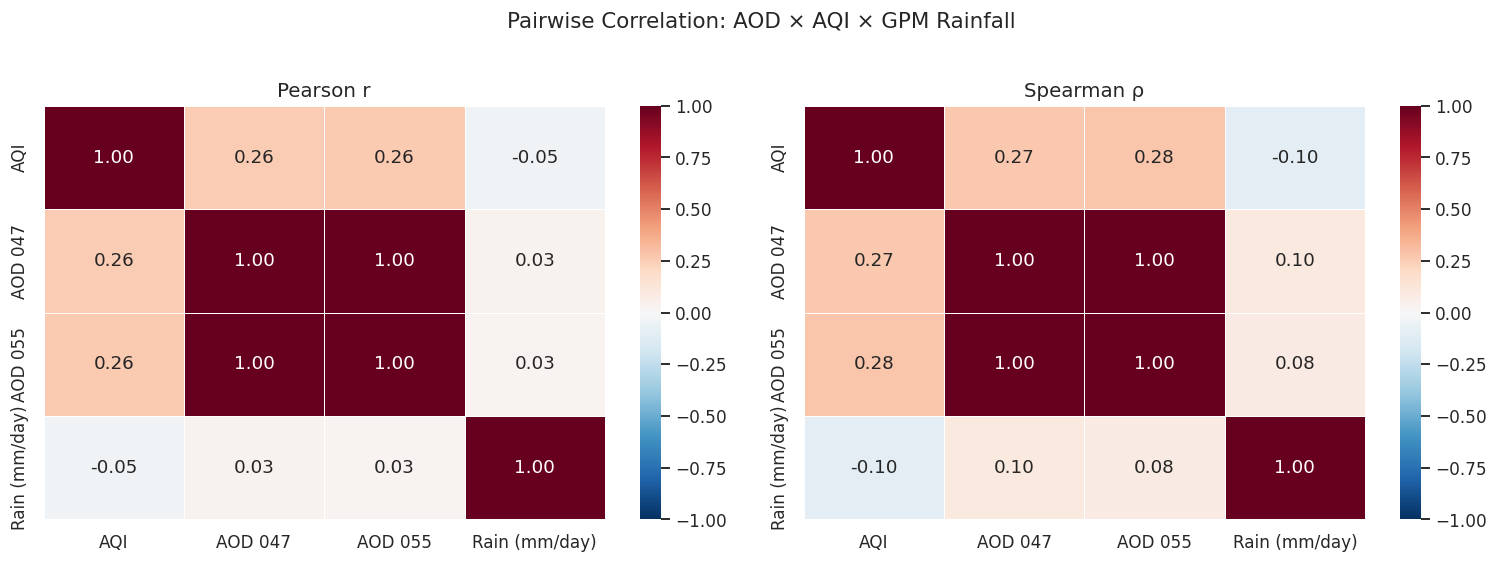


Pearson correlations:
                     AQI  Optical_Depth_047  Optical_Depth_055  \
AQI                1.000              0.257              0.264   
Optical_Depth_047  0.257              1.000              0.999   
Optical_Depth_055  0.264              0.999              1.000   
total_accum_day   -0.045              0.033              0.027   

                   total_accum_day  
AQI                         -0.045  
Optical_Depth_047            0.033  
Optical_Depth_055            0.027  
total_accum_day              1.000  

Spearman correlations:
                     AQI  Optical_Depth_047  Optical_Depth_055  \
AQI                1.000              0.269              0.277   
Optical_Depth_047  0.269              1.000              0.998   
Optical_Depth_055  0.277              0.998              1.000   
total_accum_day   -0.104              0.097              0.084   

                   total_accum_day  
AQI                         -0.104  
Optical_Depth_047            0.0

In [14]:
VARS = ['AQI', 'Optical_Depth_047', 'Optical_Depth_055', 'total_accum_day']
LABELS = ['AQI', 'AOD 047', 'AOD 055', 'Rain (mm/day)']

corr_pearson  = df[VARS].corr(method='pearson')
corr_spearman = df[VARS].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, corr, title in zip(axes,
                            [corr_pearson, corr_spearman],
                            ['Pearson r', 'Spearman ρ']):
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
                vmin=-1, vmax=1, center=0,
                xticklabels=LABELS, yticklabels=LABELS,
                linewidths=0.5, ax=ax)
    ax.set_title(title, fontsize=13)

plt.suptitle('Pairwise Correlation: AOD × AQI × GPM Rainfall', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nPearson correlations:")
print(corr_pearson.round(3))
print("\nSpearman correlations:")
print(corr_spearman.round(3))

## 7. Scatter Matrix — All Three Variables

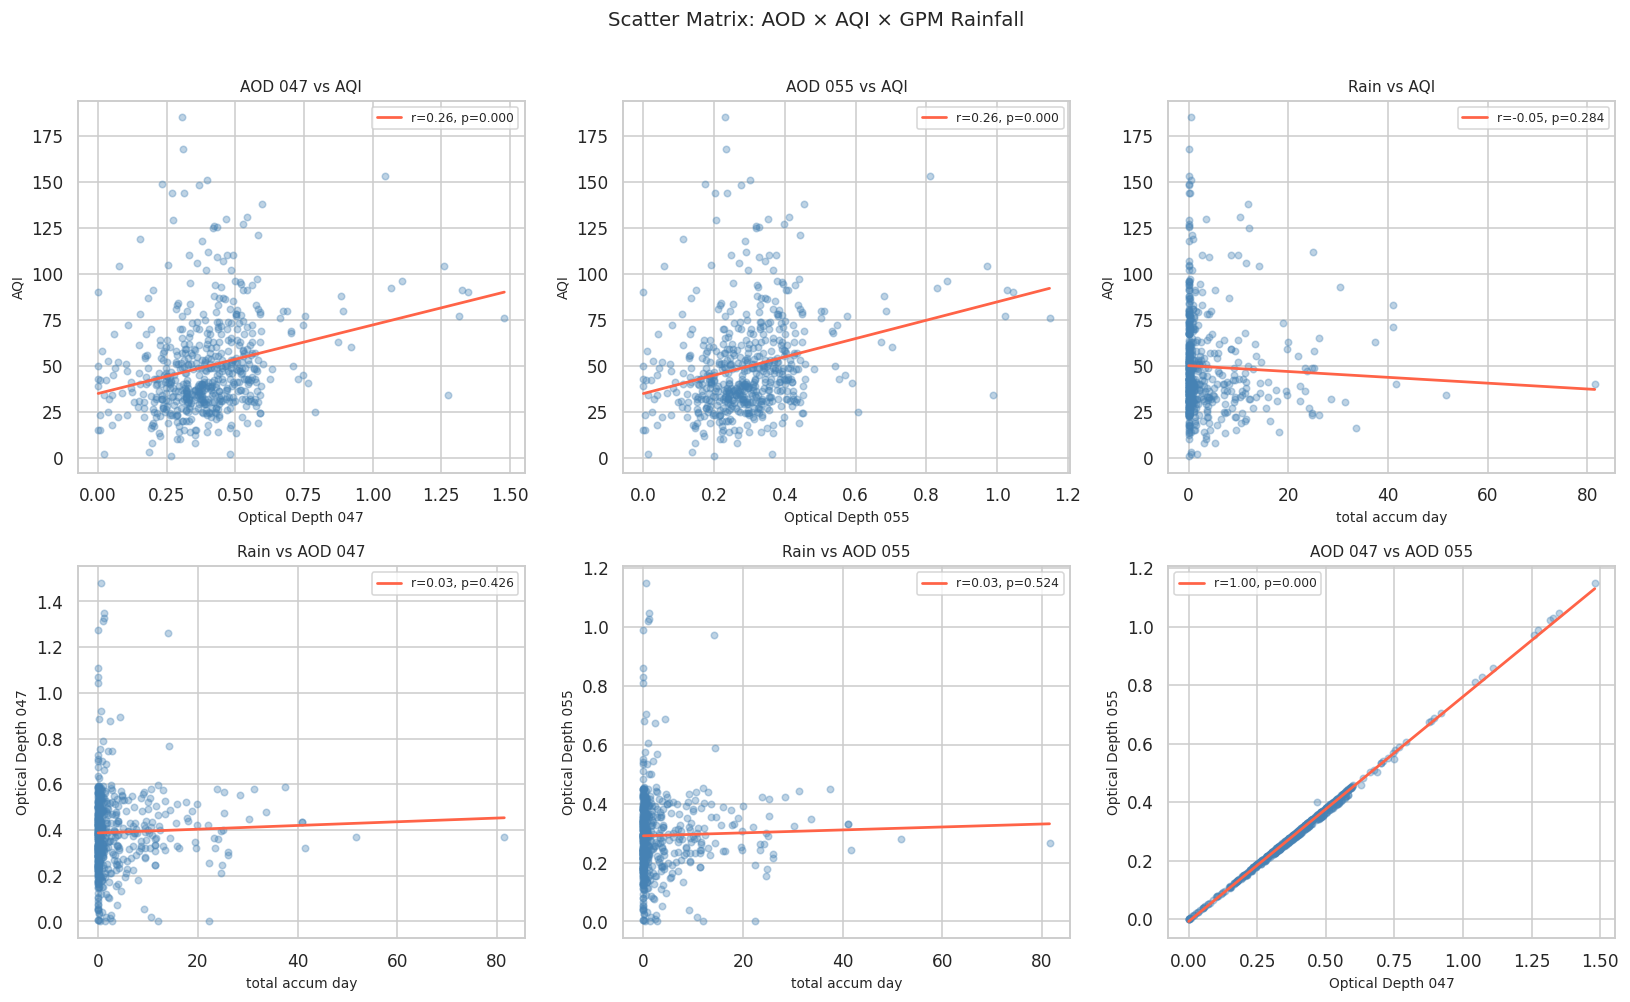

In [15]:
df_plot = df[VARS].dropna()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
pairs = [
    ('Optical_Depth_047', 'AQI',          'AOD 047 vs AQI'),
    ('Optical_Depth_055', 'AQI',          'AOD 055 vs AQI'),
    ('total_accum_day',       'AQI',          'Rain vs AQI'),
    ('total_accum_day',       'Optical_Depth_047', 'Rain vs AOD 047'),
    ('total_accum_day',       'Optical_Depth_055', 'Rain vs AOD 055'),
    ('Optical_Depth_047', 'Optical_Depth_055', 'AOD 047 vs AOD 055'),
]

for ax, (x, y, title) in zip(axes.flat, pairs):
    sub = df_plot[[x, y]].dropna()
    ax.scatter(sub[x], sub[y], alpha=0.35, s=18, color='steelblue')
    # OLS trend line
    if len(sub) > 2:
        m, b, r, p, _ = stats.linregress(sub[x], sub[y])
        xs = np.linspace(sub[x].min(), sub[x].max(), 200)
        ax.plot(xs, m * xs + b, color='tomato', lw=1.8,
                label=f'r={r:.2f}, p={p:.3f}')
        ax.legend(fontsize=8)
    ax.set_xlabel(x.replace('_', ' '), fontsize=9)
    ax.set_ylabel(y.replace('_', ' '), fontsize=9)
    ax.set_title(title, fontsize=10)

plt.suptitle('Scatter Matrix: AOD × AQI × GPM Rainfall', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Rain Washout Effect — AOD and AQI by Rainfall Bin

Split days into **dry** (rain < 1 mm), **light rain** (1–10 mm), and **heavy rain** (> 10 mm)  
and compare distributions of AQI and AOD across bins.

Records per rainfall bin:
rain_bin
Dry (<1 mm)        350
Light (1–10 mm)    151
Heavy (>10 mm)      67
Name: count, dtype: int64


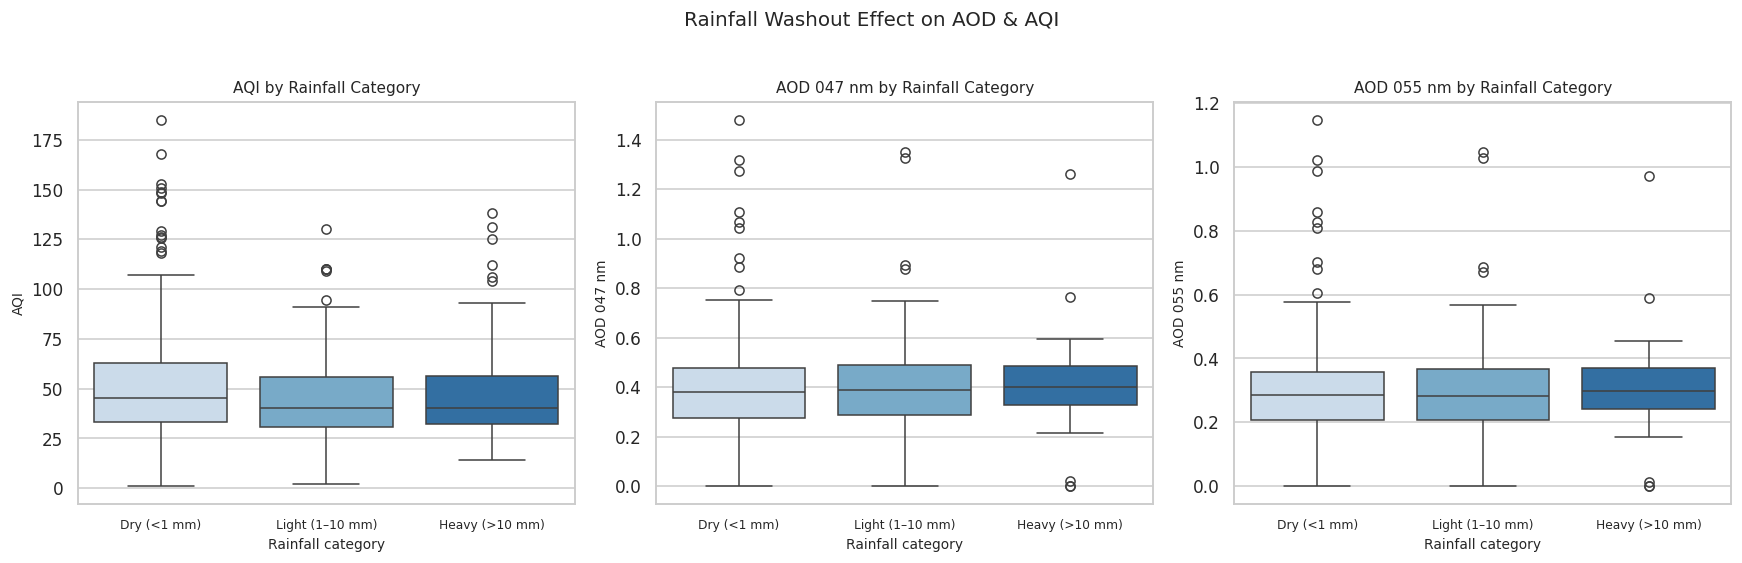

In [16]:
bins   = [-np.inf, 1, 10, np.inf]
labels = ['Dry (<1 mm)', 'Light (1–10 mm)', 'Heavy (>10 mm)']

df['rain_bin'] = pd.cut(df['total_accum_day'], bins=bins, labels=labels)

print("Records per rainfall bin:")
print(df['rain_bin'].value_counts().sort_index())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, label in zip(axes,
                           ['AQI', 'Optical_Depth_047', 'Optical_Depth_055'],
                           ['AQI', 'AOD 047 nm', 'AOD 055 nm']):
    sub = df[['rain_bin', col]].dropna()
    sns.boxplot(data=sub, x='rain_bin', y=col,
                order=labels, palette='Blues', ax=ax)
    ax.set_xlabel('Rainfall category', fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(f'{label} by Rainfall Category', fontsize=10)
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Rainfall Washout Effect on AOD & AQI', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# ── ANOVA / Kruskal-Wallis test across rain bins ──────────────────────────
print("Kruskal-Wallis test (non-parametric ANOVA across rain bins)\n")
for col, label in zip(['AQI', 'Optical_Depth_047', 'Optical_Depth_055'],
                      ['AQI', 'AOD 047', 'AOD 055']):
    groups = [df.loc[df['rain_bin'] == b, col].dropna().values for b in labels]
    groups = [g for g in groups if len(g) >= 3]
    if len(groups) >= 2:
        h, p = stats.kruskal(*groups)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f"{label:20s}  H={h:.2f}  p={p:.4f}  {sig}")

Kruskal-Wallis test (non-parametric ANOVA across rain bins)

AQI                   H=6.80  p=0.0334  *
AOD 047               H=3.07  p=0.2152  ns
AOD 055               H=2.46  p=0.2921  ns


## 9. Temporal Lag Analysis — Does Rainfall Lead AOD/AQI Reduction?

Shift GPM rainfall by 0, 1, 2, 3 days and compute Spearman correlation  
with same-day AOD / AQI to find the optimal washout lag.

In [18]:
MAX_LAG = 4   # days

lag_results = []
for lag in range(MAX_LAG + 1):
    tmp = df[['station_id', 'date', 'AQI', 'Optical_Depth_047',
              'Optical_Depth_055', 'total_accum_day']].copy()
    tmp['date_shifted'] = tmp['date'] + pd.Timedelta(days=lag)

    merged_lag = df[['station_id', 'date', 'AQI',
                     'Optical_Depth_047', 'Optical_Depth_055']].merge(
        tmp[['station_id', 'date_shifted', 'total_accum_day']].rename(
            columns={'date_shifted': 'date'}),
        on=['station_id', 'date'],
        how='inner'
    ).dropna()

    for target, tlabel in [('AQI', 'AQI'),
                            ('Optical_Depth_047', 'AOD 047'),
                            ('Optical_Depth_055', 'AOD 055')]:
        if len(merged_lag) < 5:
            continue
        r, p = stats.spearmanr(merged_lag['total_accum_day'], merged_lag[target])
        lag_results.append({'lag_days': lag, 'target': tlabel,
                            'spearman_r': r, 'p_value': p,
                            'n': len(merged_lag)})

df_lag = pd.DataFrame(lag_results)
print(df_lag.to_string(index=False))

 lag_days  target  spearman_r  p_value   n
        0     AQI   -0.103682 0.013426 568
        0 AOD 047    0.097282 0.020401 568
        0 AOD 055    0.084166 0.044958 568
        1     AQI   -0.119371 0.067745 235
        1 AOD 047    0.024058 0.713702 235
        1 AOD 055    0.014025 0.830656 235
        2     AQI   -0.087414 0.217225 201
        2 AOD 047   -0.103161 0.145027 201
        2 AOD 055   -0.115865 0.101434 201
        3     AQI   -0.173473 0.015297 195
        3 AOD 047   -0.040944 0.569823 195
        3 AOD 055   -0.050677 0.481698 195
        4     AQI    0.147636 0.049227 178
        4 AOD 047    0.097257 0.196533 178
        4 AOD 055    0.091474 0.224606 178


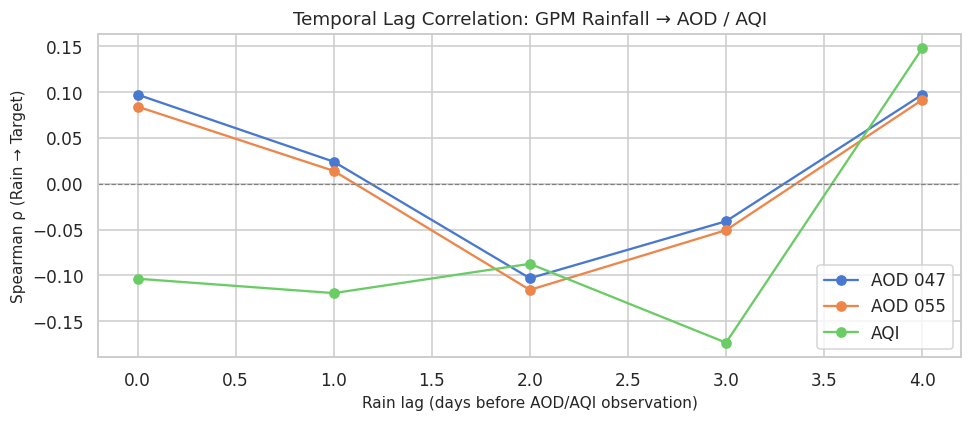

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
for target, group in df_lag.groupby('target'):
    ax.plot(group['lag_days'], group['spearman_r'],
            marker='o', label=target)

ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Rain lag (days before AOD/AQI observation)', fontsize=10)
ax.set_ylabel('Spearman ρ (Rain → Target)', fontsize=10)
ax.set_title('Temporal Lag Correlation: GPM Rainfall → AOD / AQI', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

## 10. Per-Station Correlation Summary Table

In [20]:
station_rows = []
for sid, grp in df.groupby('station_id'):
    sub = grp.dropna(subset=['AQI', 'Optical_Depth_047',
                              'Optical_Depth_055', 'total_accum_day'])
    if len(sub) < MIN_OBS:
        continue

    row = {'station_id': sid, 'n': len(sub)}
    for x, y, key in [
        ('Optical_Depth_047', 'AQI',           'r_AOD047_AQI'),
        ('Optical_Depth_055', 'AQI',           'r_AOD055_AQI'),
        ('total_accum_day',       'AQI',           'r_rain_AQI'),
        ('total_accum_day',       'Optical_Depth_047', 'r_rain_AOD047'),
        ('total_accum_day',       'Optical_Depth_055', 'r_rain_AOD055'),
    ]:
        pair = sub[[x, y]].dropna()
        if len(pair) >= MIN_OBS:
            r, p = stats.spearmanr(pair[x], pair[y])
        else:
            r, p = np.nan, np.nan
        row[key] = round(r, 3)
        row[key + '_p'] = round(p, 4) if not np.isnan(p) else np.nan
    station_rows.append(row)

df_station_corr = pd.DataFrame(station_rows)
print(f"Per-station correlation table ({len(df_station_corr)} stations):")
df_station_corr

Per-station correlation table (13 stations):


,station_id,n,r_AOD047_AQI,r_AOD047_AQI_p,r_AOD055_AQI,r_AOD055_AQI_p,r_rain_AQI,r_rain_AQI_p,r_rain_AOD047,r_rain_AOD047_p,r_rain_AOD055,r_rain_AOD055_p
0,28505268571336961948594948504,40,0.597,0.0000,0.597,0.0000,-0.161,0.3209,0.210,0.1932,0.211,0.1908
1,28560877461938780203765592307,37,0.344,0.0368,0.342,0.0382,-0.245,0.1439,0.039,0.8207,0.042,0.8067
2,29195707587706641566224751462,38,0.293,0.0739,0.293,0.0739,-0.068,0.6842,-0.050,0.7634,-0.050,0.7634
3,29213751141295132066317063859,56,0.202,0.1345,0.204,0.1313,0.085,0.5337,-0.028,0.8384,-0.020,0.8841
4,31387251434693138681789561386,41,0.282,0.0741,0.282,0.0741,-0.223,0.1605,0.068,0.6740,0.068,0.6740
5,31388839920718814259329251882,43,0.135,0.3885,0.135,0.3885,0.269,0.0807,-0.027,0.8637,-0.027,0.8637
6,31388851800421997746903202346,93,0.251,0.0152,0.252,0.0147,-0.199,0.0558,0.178,0.0885,0.179,0.0857
7,31388883344354363840031242796,45,0.222,0.1420,0.222,0.1420,-0.009,0.9522,0.253,0.0939,0.253,0.0939
8,31390903576425084107499649578,34,0.037,0.8368,0.037,0.8375,-0.264,0.1309,0.137,0.4400,0.139,0.4345
9,31390908889087377344742439468,34,0.278,0.1119,0.282,0.1063,0.033,0.8533,0.260,0.1378,0.259,0.1387


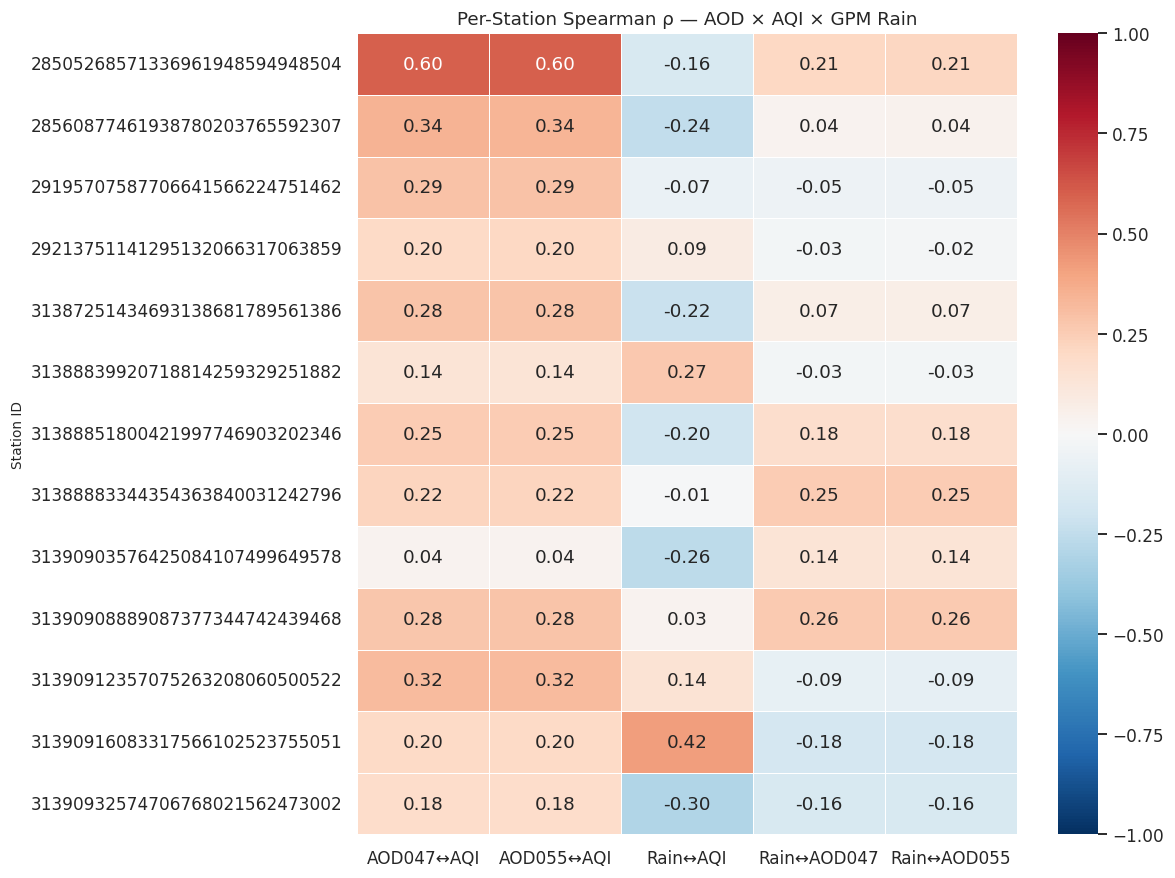

In [21]:
# ── Heatmap of per-station Spearman r values ──────────────────────────────
r_cols = ['r_AOD047_AQI', 'r_AOD055_AQI',
          'r_rain_AQI', 'r_rain_AOD047', 'r_rain_AOD055']
r_labels = ['AOD047↔AQI', 'AOD055↔AQI',
             'Rain↔AQI', 'Rain↔AOD047', 'Rain↔AOD055']

heat = df_station_corr.set_index('station_id')[r_cols]

fig, ax = plt.subplots(figsize=(11, max(4, len(heat) * 0.55 + 1)))
sns.heatmap(heat, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0,
            xticklabels=r_labels, linewidths=0.4, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Station ID', fontsize=9)
ax.set_title('Per-Station Spearman ρ — AOD × AQI × GPM Rain', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Multivariate Regression: AOD + Rain → AQI

Does adding GPM rainfall as a feature improve AQI prediction beyond AOD alone?

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

complete = df[['AQI', 'Optical_Depth_047', 'Optical_Depth_055',
               'total_accum_day']].dropna()
y = complete['AQI'].values

feature_sets = {
    'AOD047 only':           ['Optical_Depth_047'],
    'AOD055 only':           ['Optical_Depth_055'],
    'AOD047 + AOD055':       ['Optical_Depth_047', 'Optical_Depth_055'],
    'AOD047 + Rain':         ['Optical_Depth_047', 'total_accum_day'],
    'AOD055 + Rain':         ['Optical_Depth_055', 'total_accum_day'],
    'AOD047 + AOD055 + Rain':['Optical_Depth_047', 'Optical_Depth_055', 'total_accum_day'],
}

cv_results = {}
for name, feats in feature_sets.items():
    X = complete[feats].values
    pipe = make_pipeline(StandardScaler(), LinearRegression())
    r2_scores = cross_val_score(pipe, X, y, cv=5, scoring='r2')
    cv_results[name] = {
        'mean_r2': r2_scores.mean(),
        'std_r2':  r2_scores.std(),
    }

df_cv = pd.DataFrame(cv_results).T.reset_index()
df_cv.columns = ['Feature set', 'Mean R² (5-fold CV)', 'Std R²']
df_cv = df_cv.sort_values('Mean R² (5-fold CV)', ascending=False)
print(df_cv.to_string(index=False))

           Feature set  Mean R² (5-fold CV)   Std R²
         AOD055 + Rain            -0.079034 0.151535
           AOD055 only            -0.079108 0.159633
       AOD047 + AOD055            -0.082731 0.165201
AOD047 + AOD055 + Rain            -0.089471 0.160776
         AOD047 + Rain            -0.089903 0.167336
           AOD047 only            -0.090460 0.175662


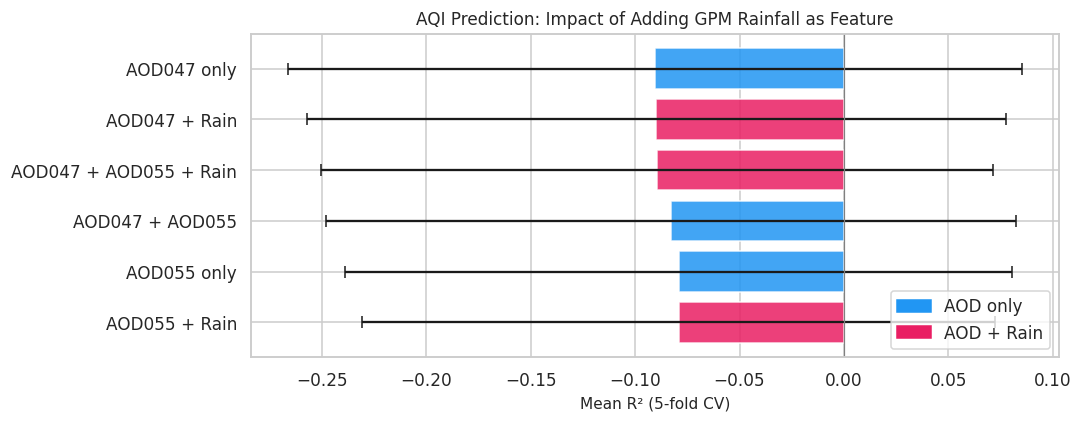

In [23]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2196F3' if 'Rain' not in n else '#E91E63' for n in df_cv['Feature set']]
bars = ax.barh(df_cv['Feature set'], df_cv['Mean R² (5-fold CV)'],
               xerr=df_cv['Std R²'], capsize=4, color=colors, alpha=0.85)
ax.set_xlabel('Mean R² (5-fold CV)', fontsize=10)
ax.set_title('AQI Prediction: Impact of Adding GPM Rainfall as Feature', fontsize=11)
ax.axvline(0, color='gray', lw=0.8)

# Annotation
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#2196F3', label='AOD only'),
                   Patch(color='#E91E63', label='AOD + Rain')],
          loc='lower right')
plt.tight_layout()
plt.show()

## 12. Spatial Overview — Station Correlations on a Map

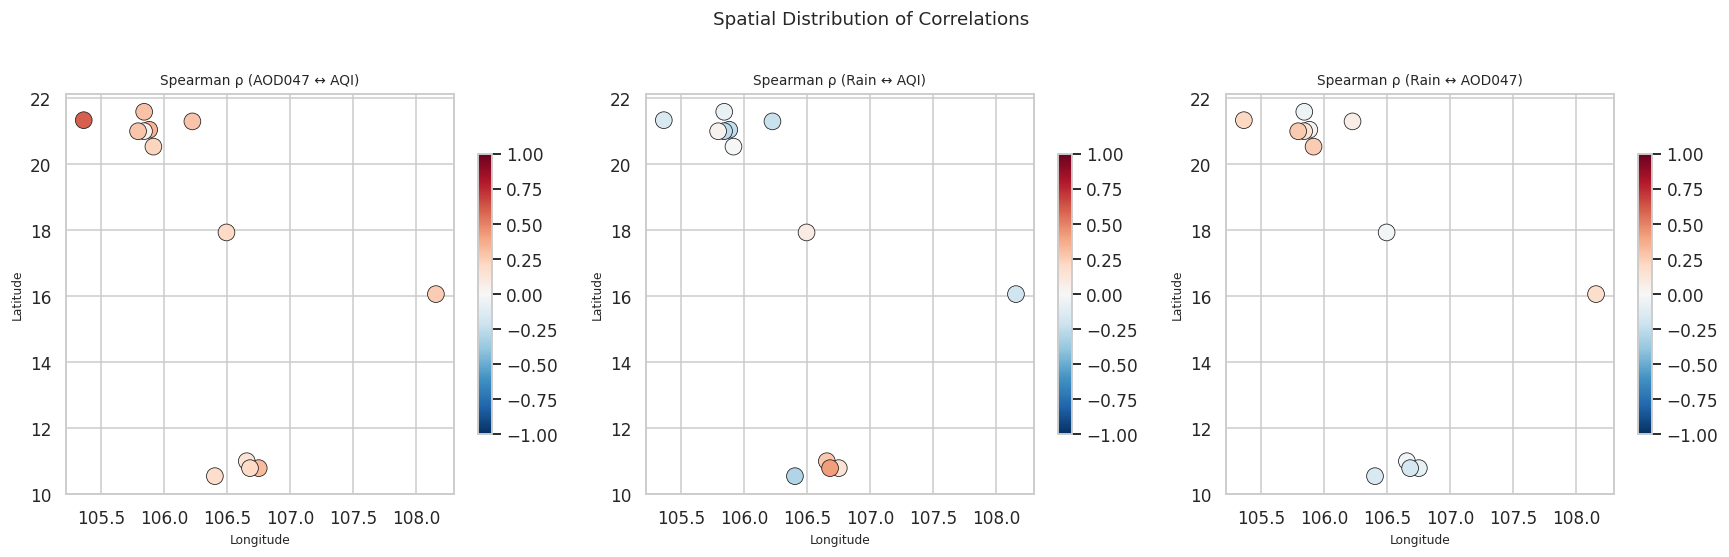

In [24]:
map_df = df_station_corr.merge(meta_coords, on='station_id', how='left').dropna(subset=['lat', 'lon'])

if len(map_df) == 0:
    print("No coordinate data available for mapping — skipping.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, col, label in zip(
        axes,
        ['r_AOD047_AQI', 'r_rain_AQI', 'r_rain_AOD047'],
        ['Spearman ρ (AOD047 ↔ AQI)',
         'Spearman ρ (Rain ↔ AQI)',
         'Spearman ρ (Rain ↔ AOD047)']
    ):
        sc = ax.scatter(map_df['lon'], map_df['lat'],
                        c=map_df[col], cmap='RdBu_r',
                        vmin=-1, vmax=1, s=120, edgecolors='k', lw=0.5)
        plt.colorbar(sc, ax=ax, shrink=0.7)
        ax.set_xlabel('Longitude', fontsize=8)
        ax.set_ylabel('Latitude', fontsize=8)
        ax.set_title(label, fontsize=9)

    plt.suptitle('Spatial Distribution of Correlations', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

## 13. Save Results

In [25]:
out_dir = Path(MODIS_AQI_DIR)

# Per-station correlation table
out_path = out_dir / "aod_aqi_gpm_station_correlations.csv"
df_station_corr.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

# Merged daily dataset
out_merged = out_dir / "aod_aqi_gpm_merged_daily.csv"
df.to_csv(out_merged, index=False)
print(f"Saved: {out_merged}")

# Lag analysis
out_lag = out_dir / "aod_aqi_gpm_lag_correlations.csv"
df_lag.to_csv(out_lag, index=False)
print(f"Saved: {out_lag}")

Saved: /home/slow_data/Air_Quality/MODIS_MCD19A2/stations_aod_v2/aod_aqi_gpm_station_correlations.csv
Saved: /home/slow_data/Air_Quality/MODIS_MCD19A2/stations_aod_v2/aod_aqi_gpm_merged_daily.csv
Saved: /home/slow_data/Air_Quality/MODIS_MCD19A2/stations_aod_v2/aod_aqi_gpm_lag_correlations.csv


## Time Series Analysis: Visualizing the Washout Effect
We align AOD, AQI, and GPM on the same temporal axis. Look specifically at peaks in the GPM (Rain) chart and observe the subsequent drops in the AQI and AOD charts.

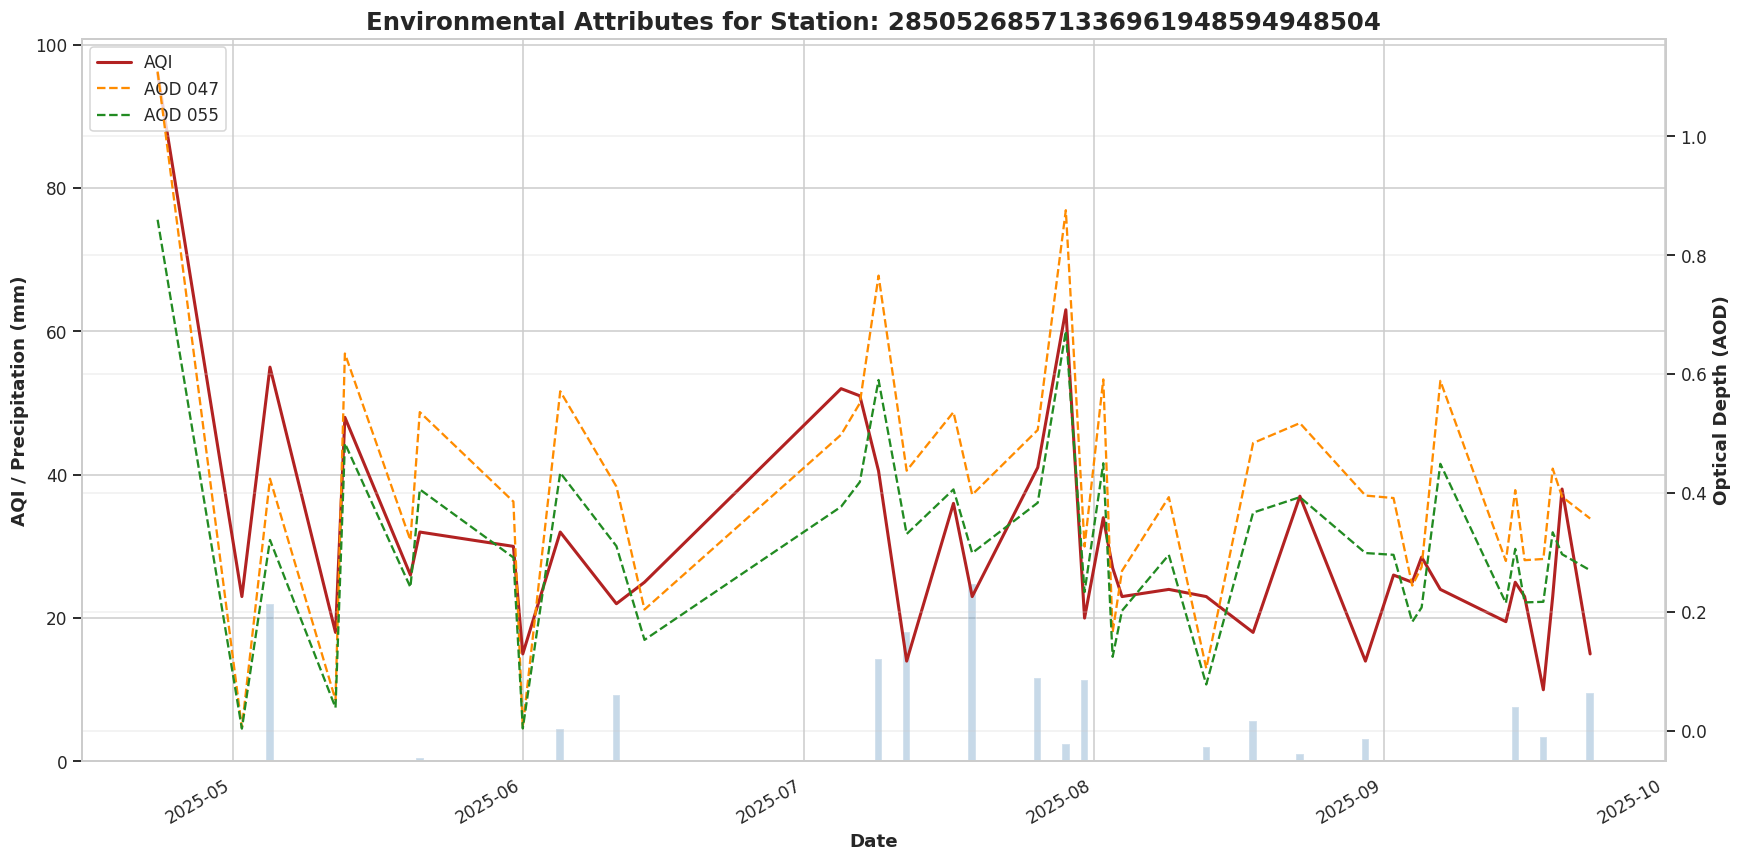

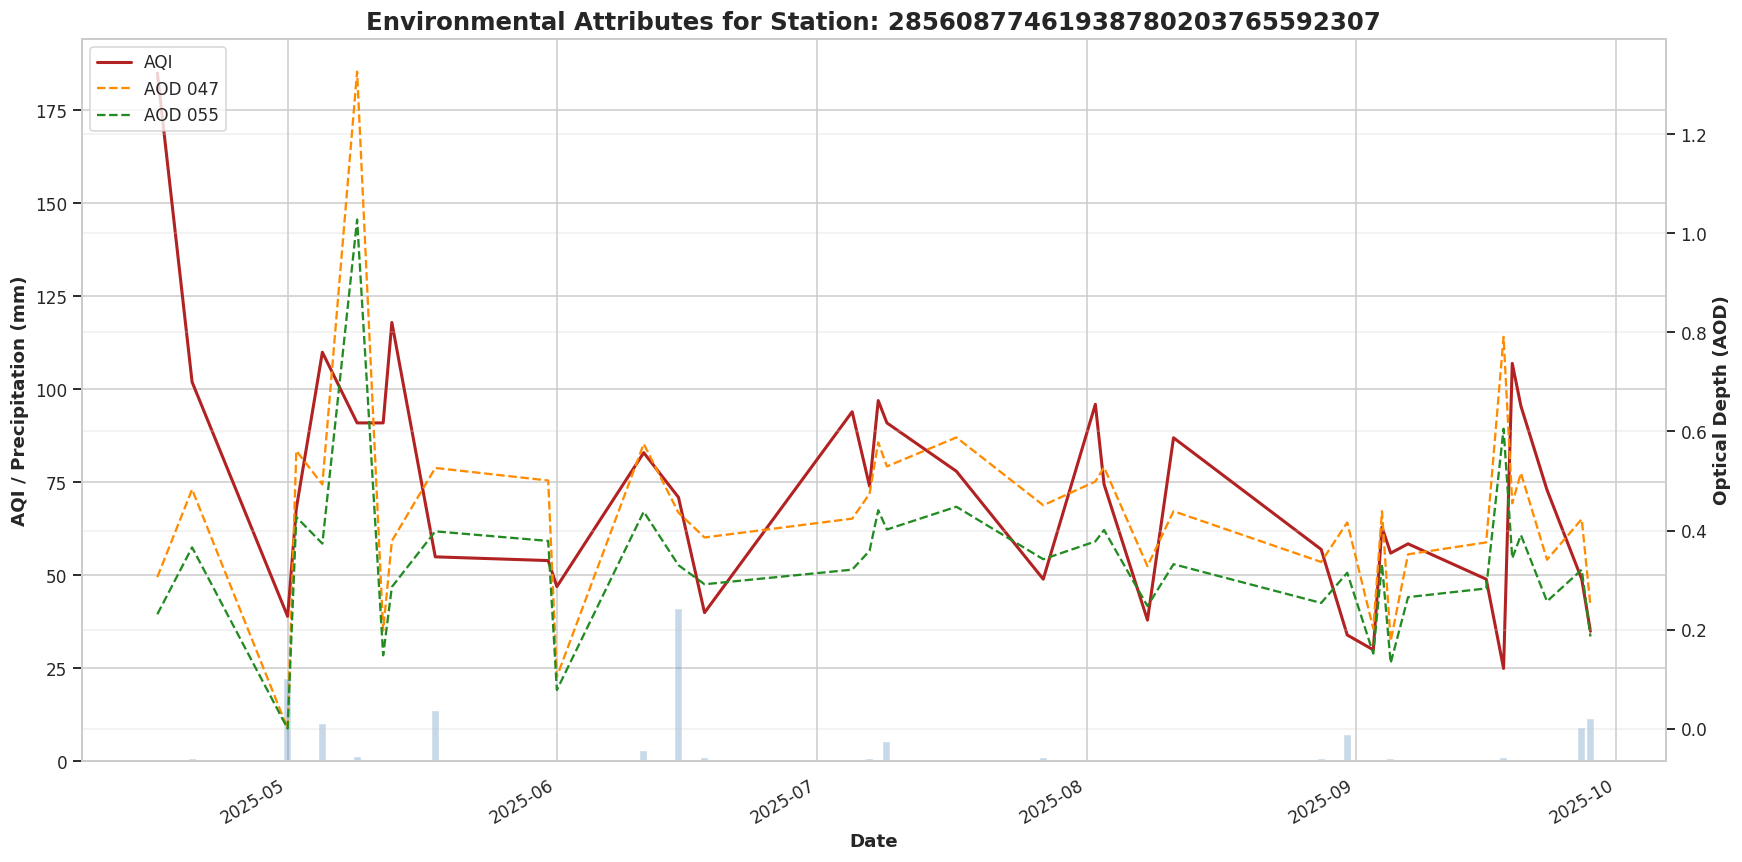

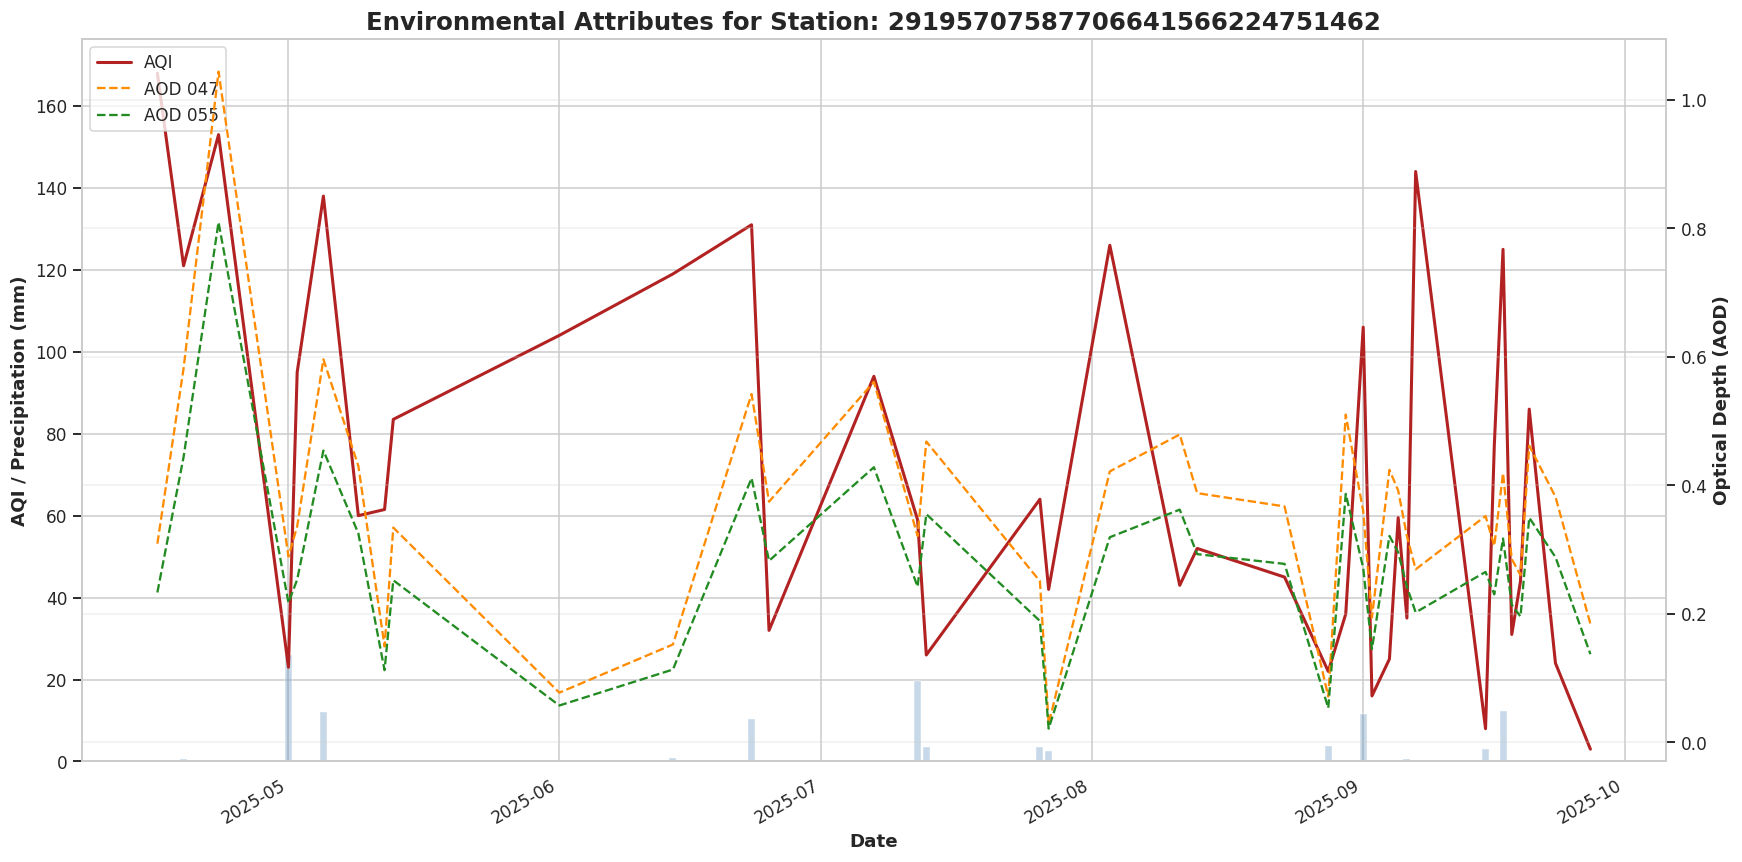

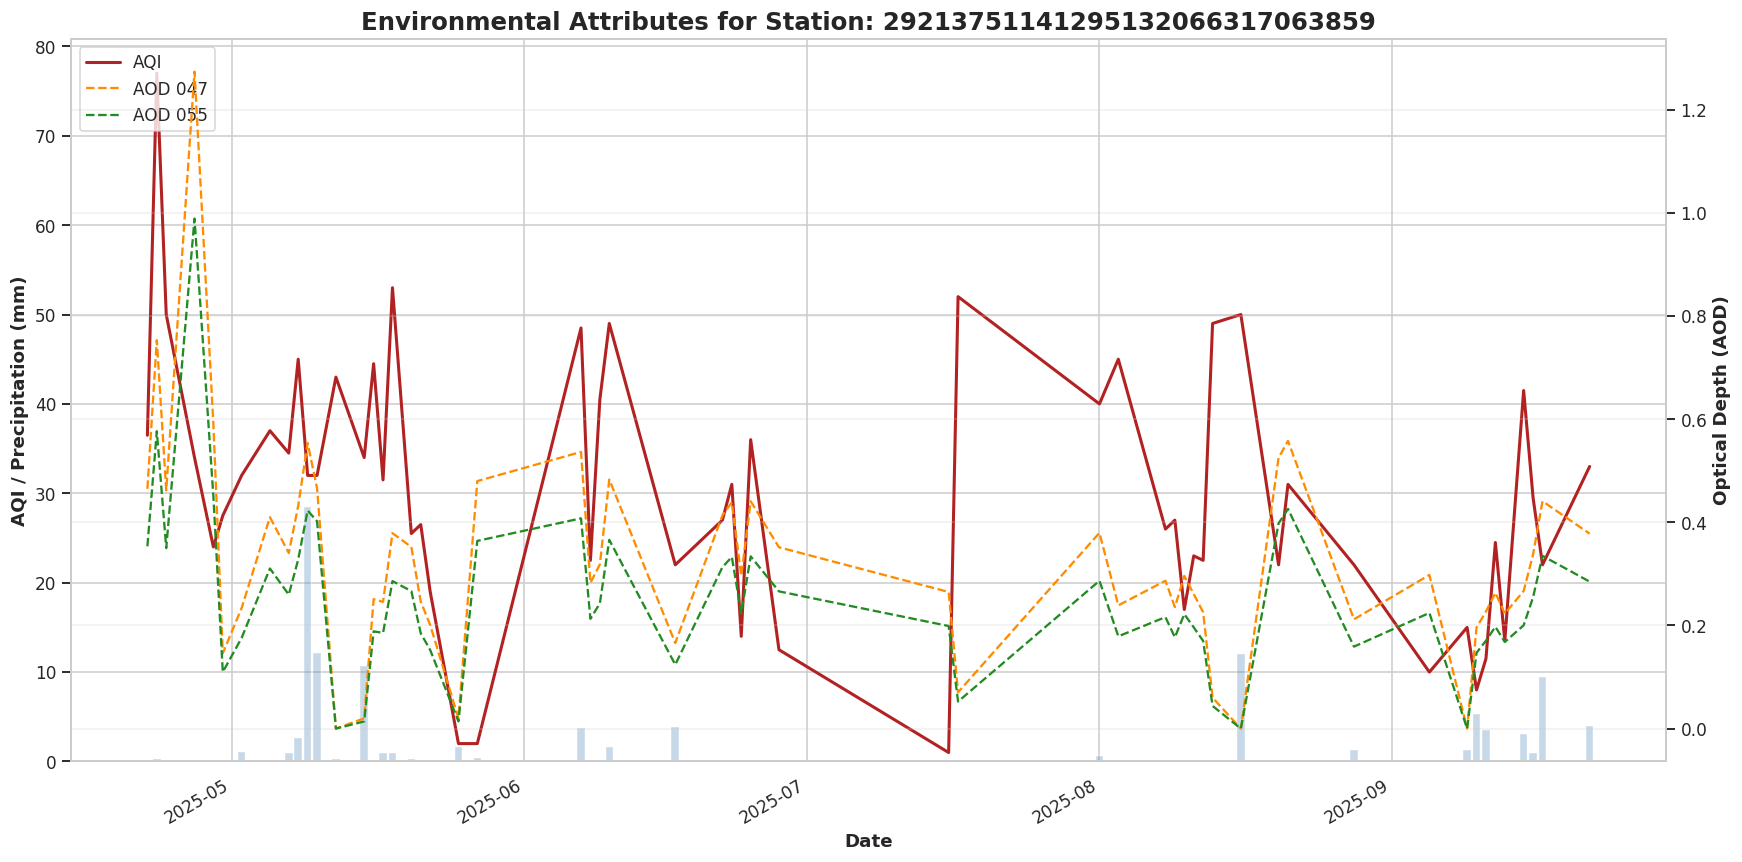

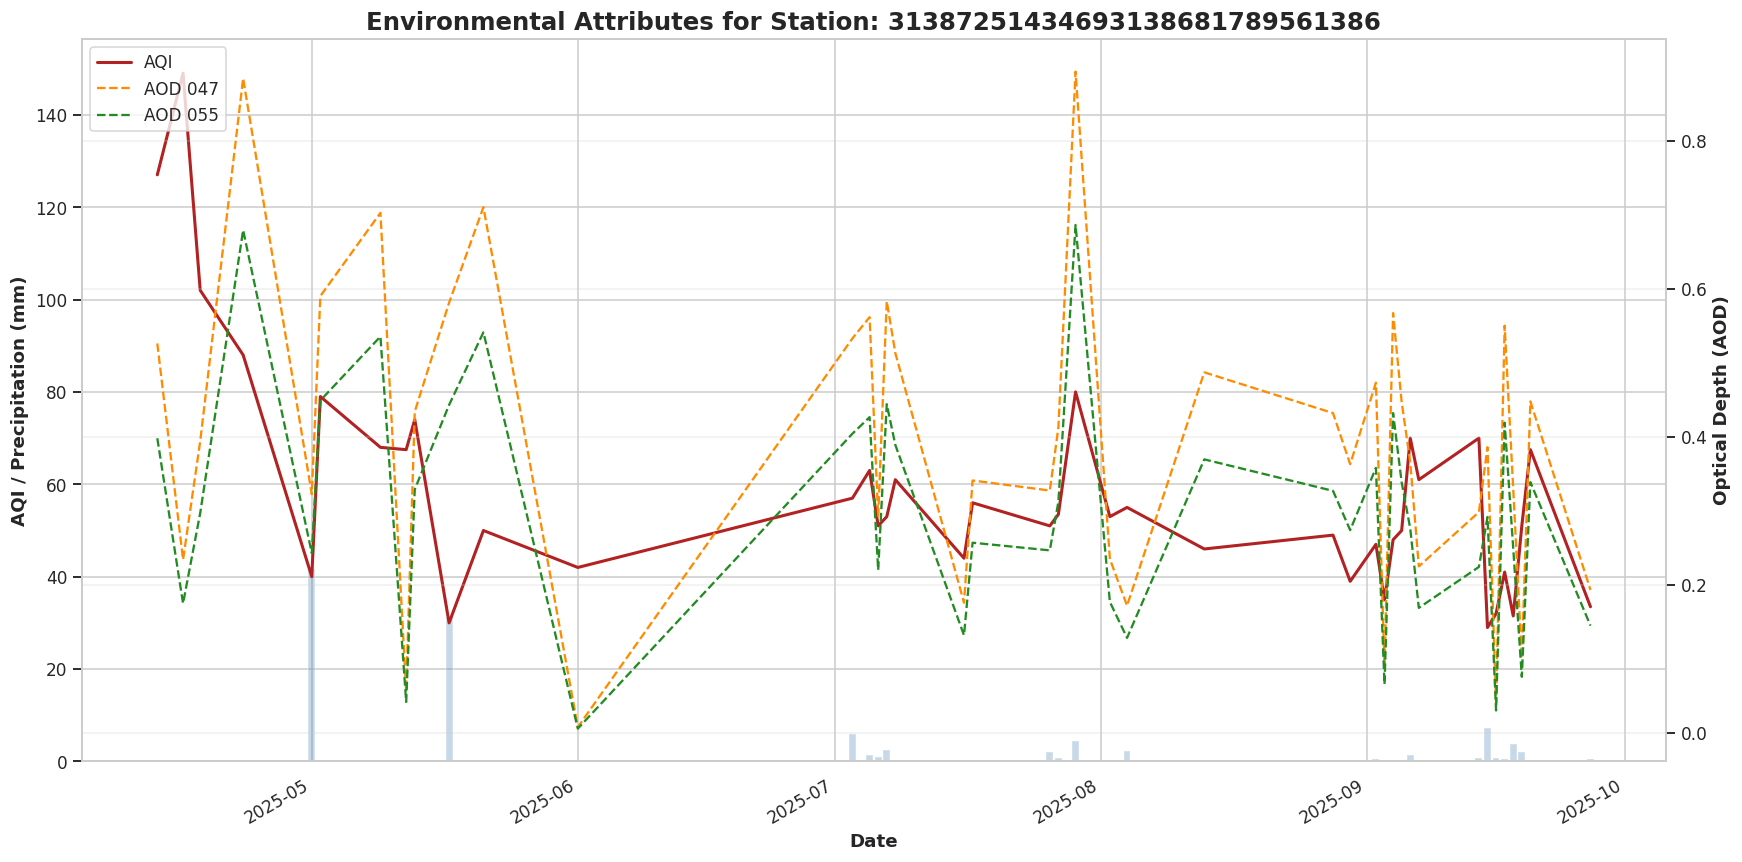

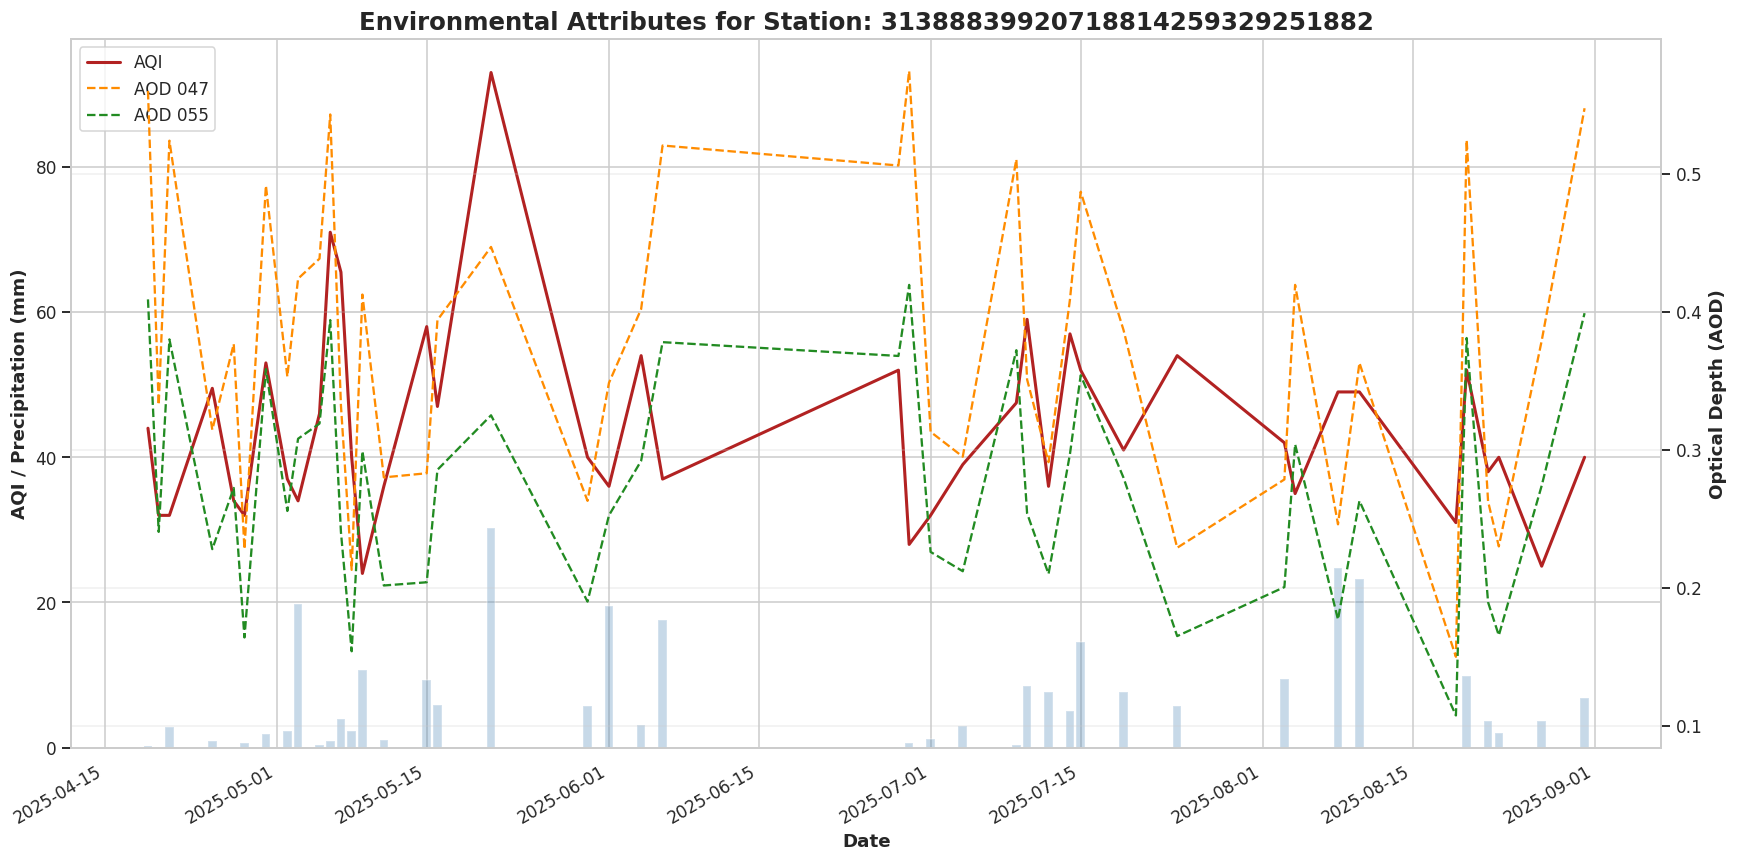

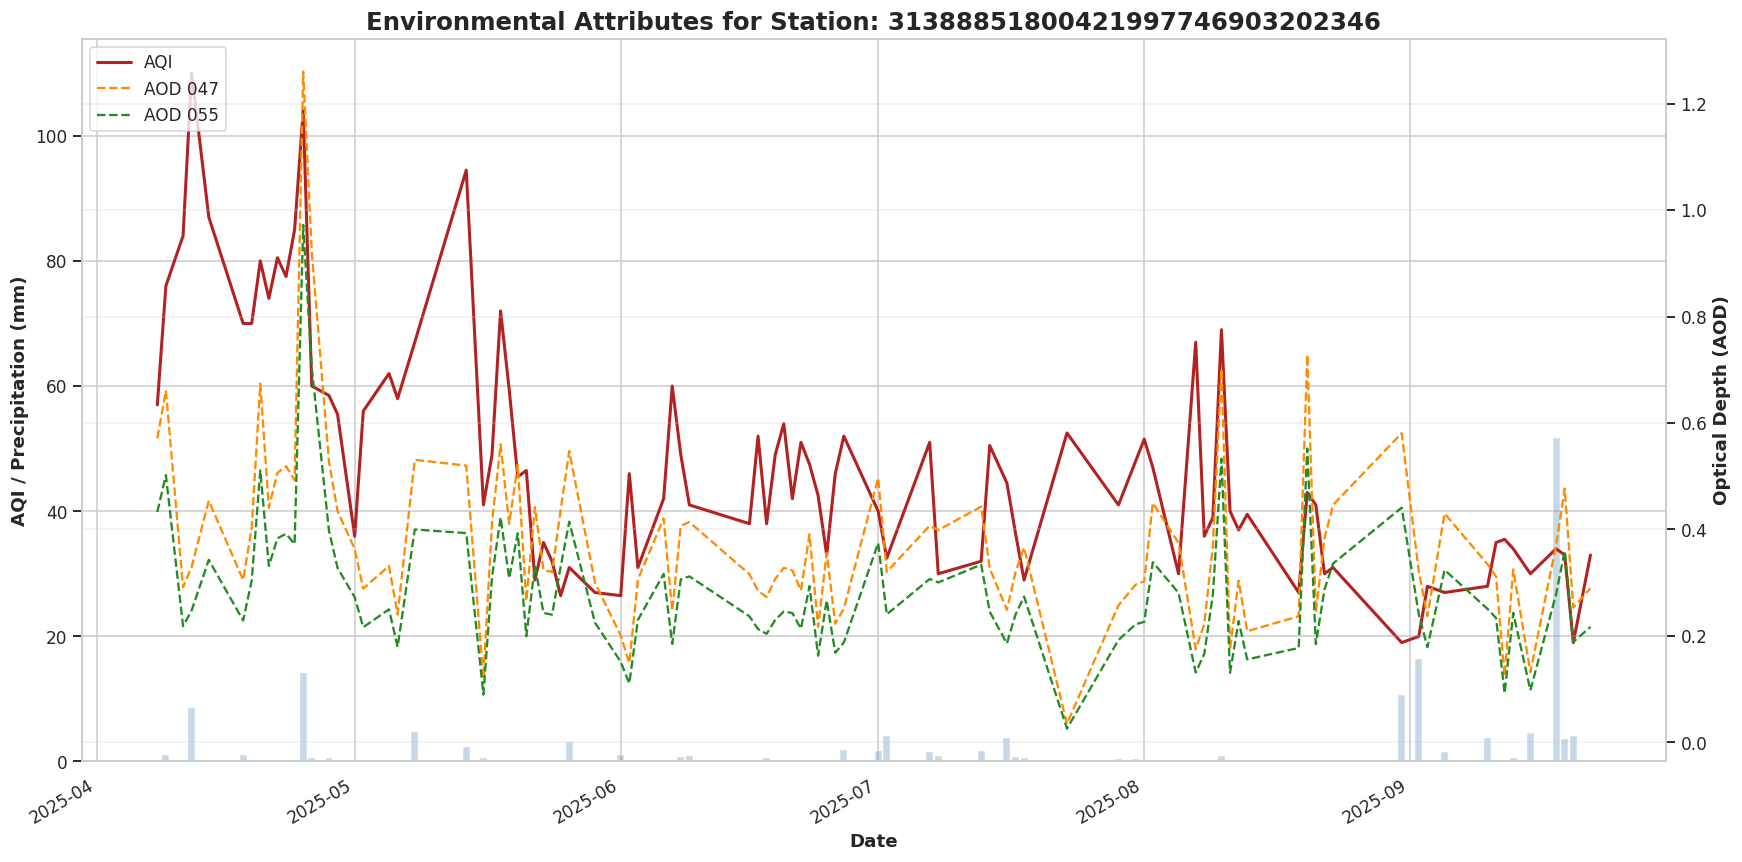

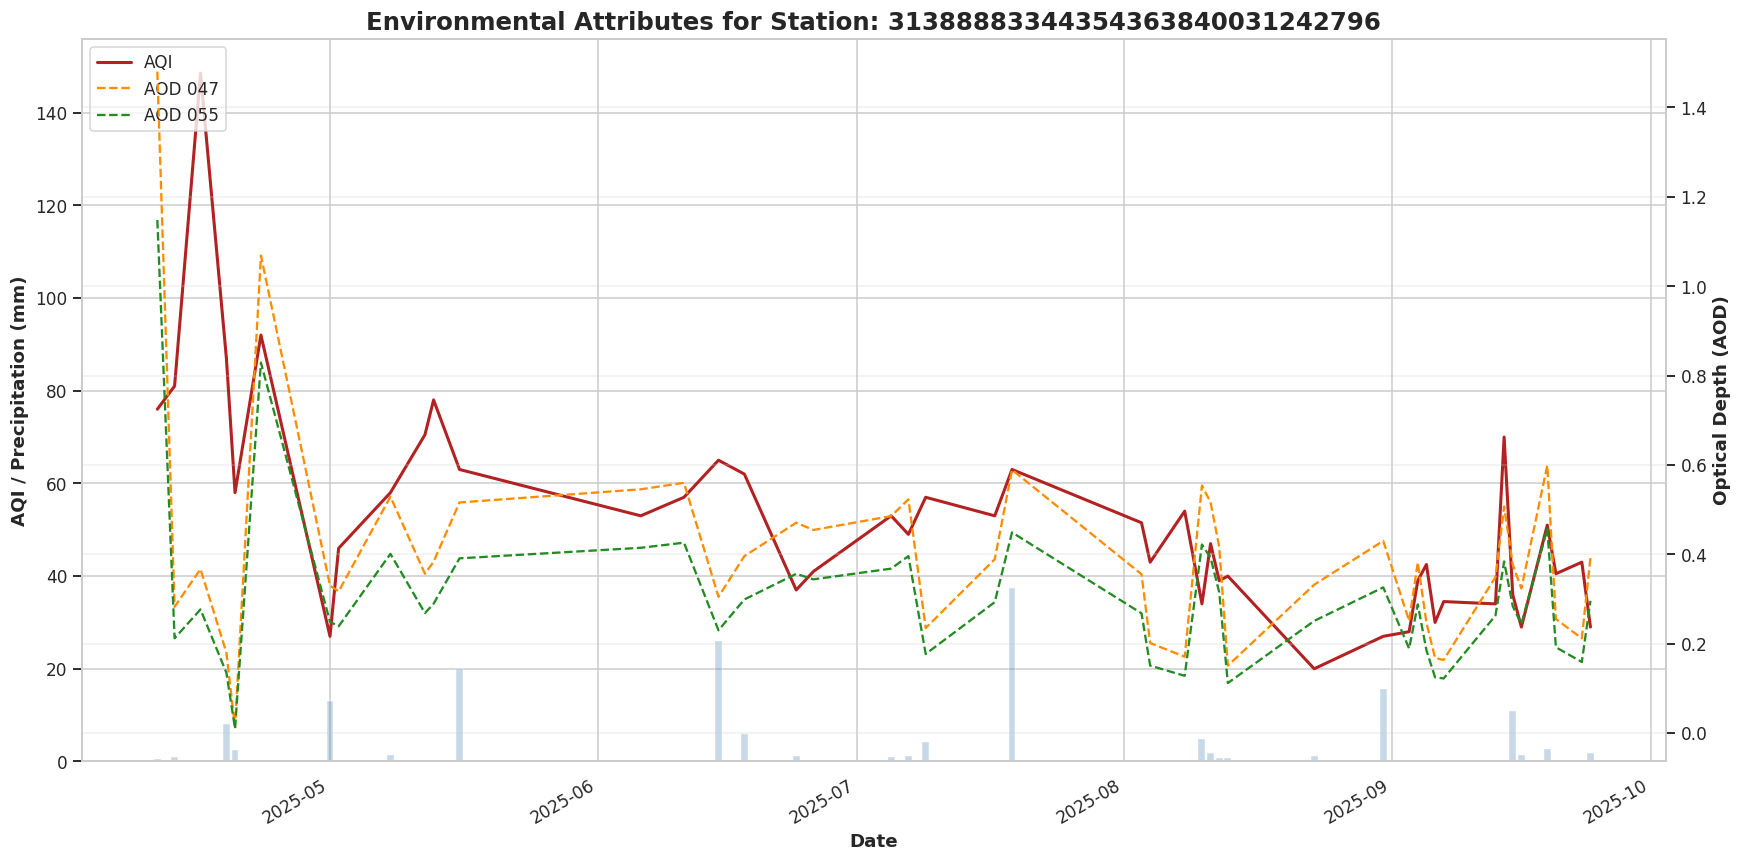

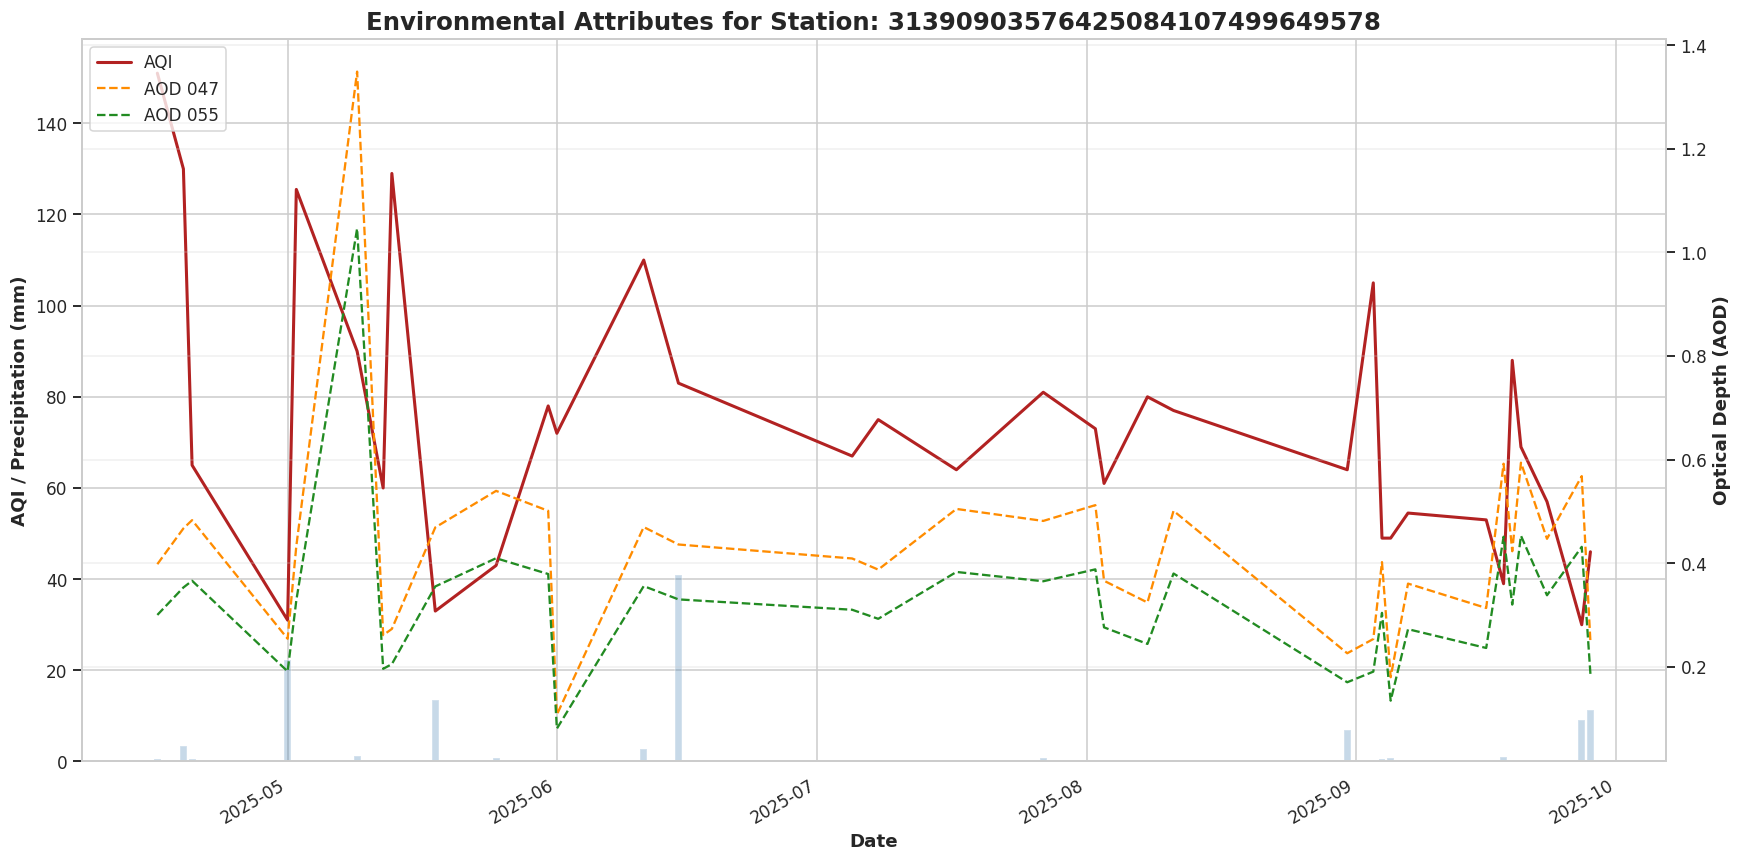

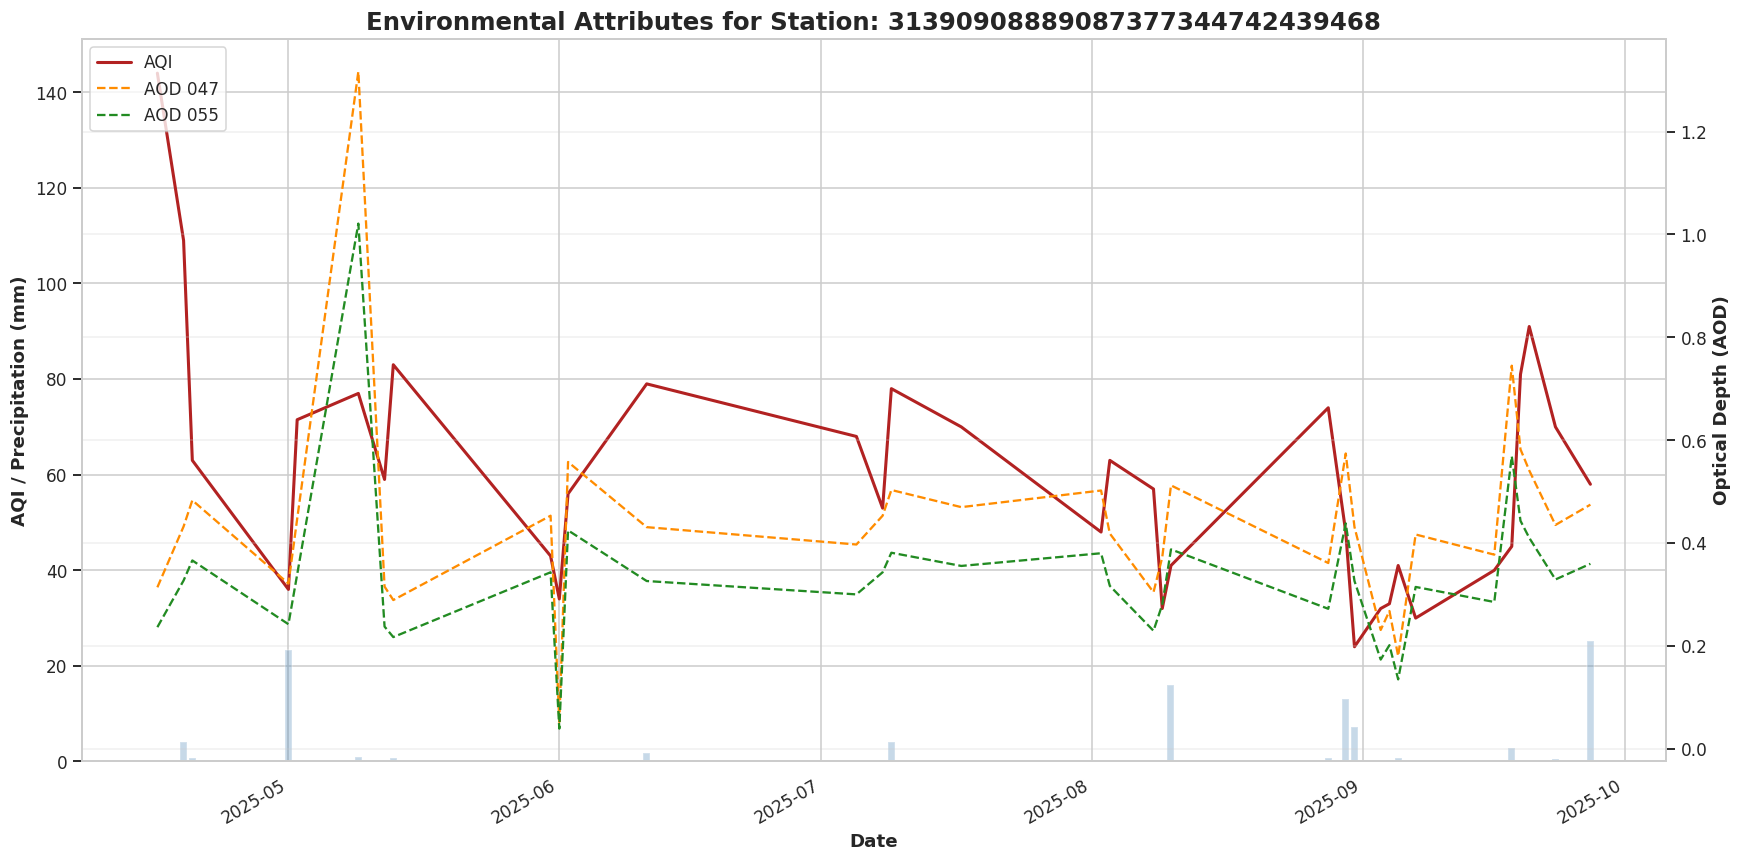

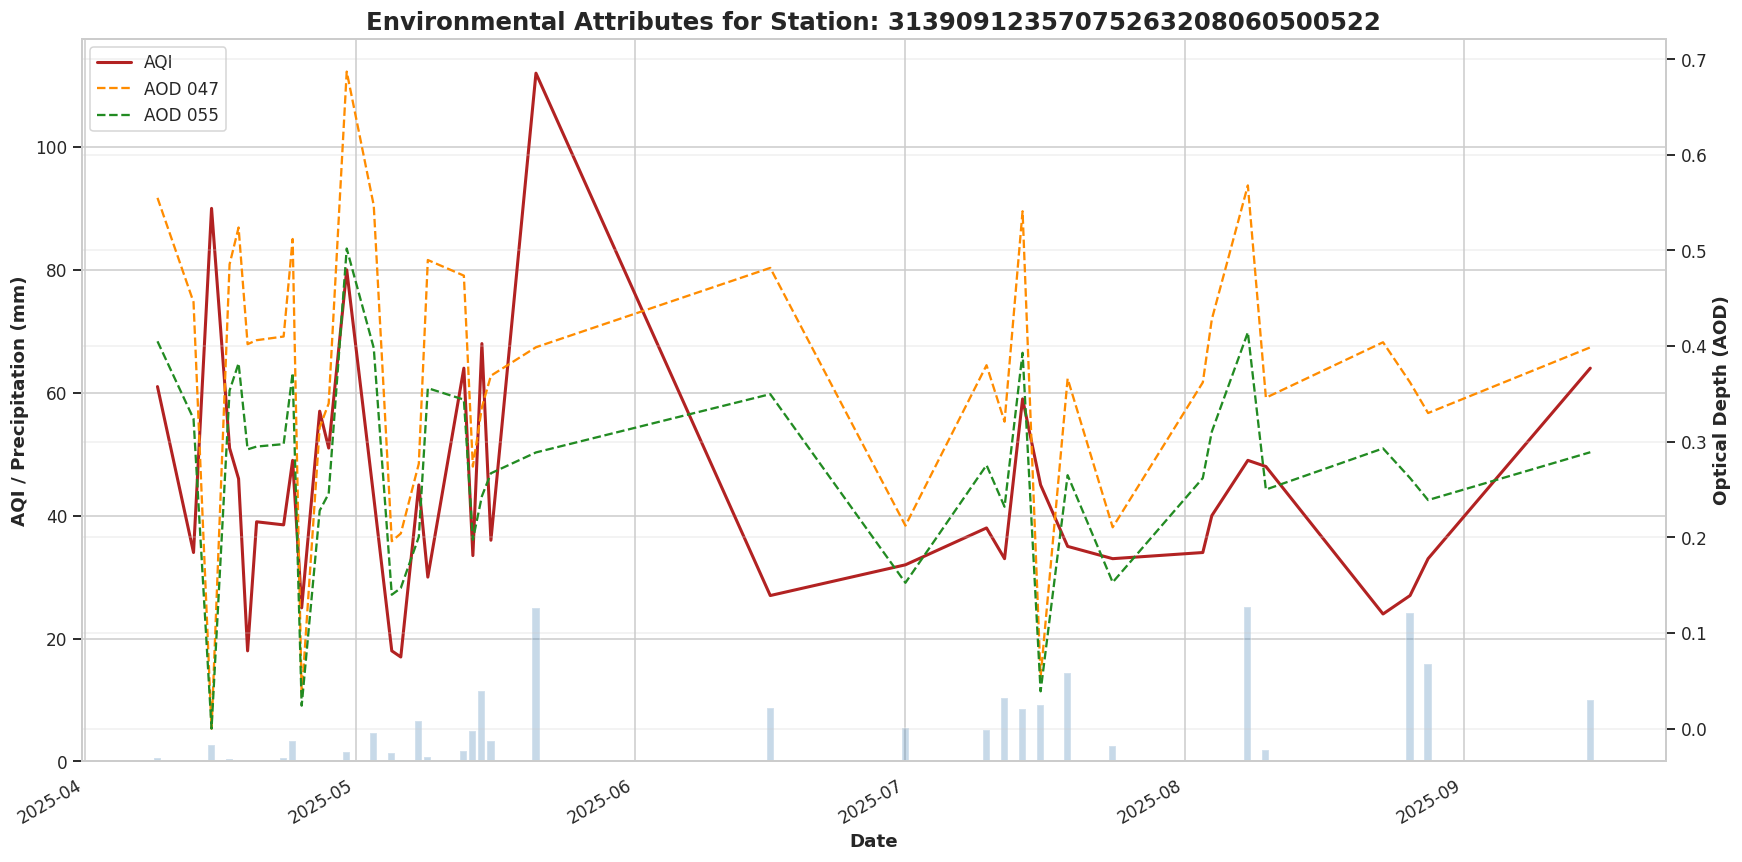

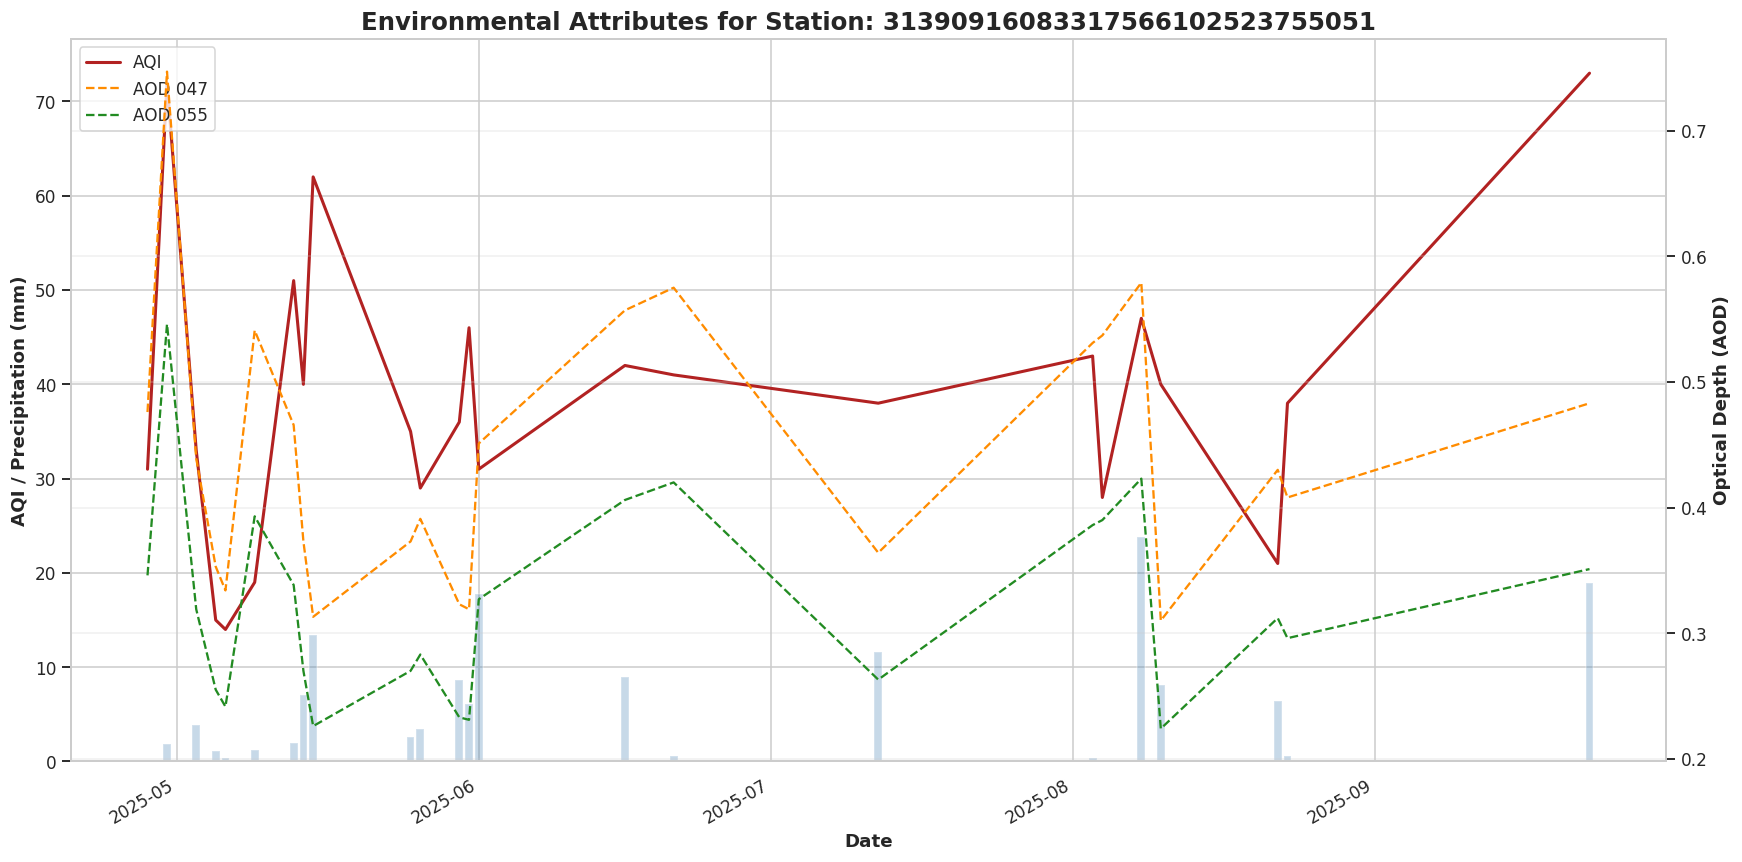

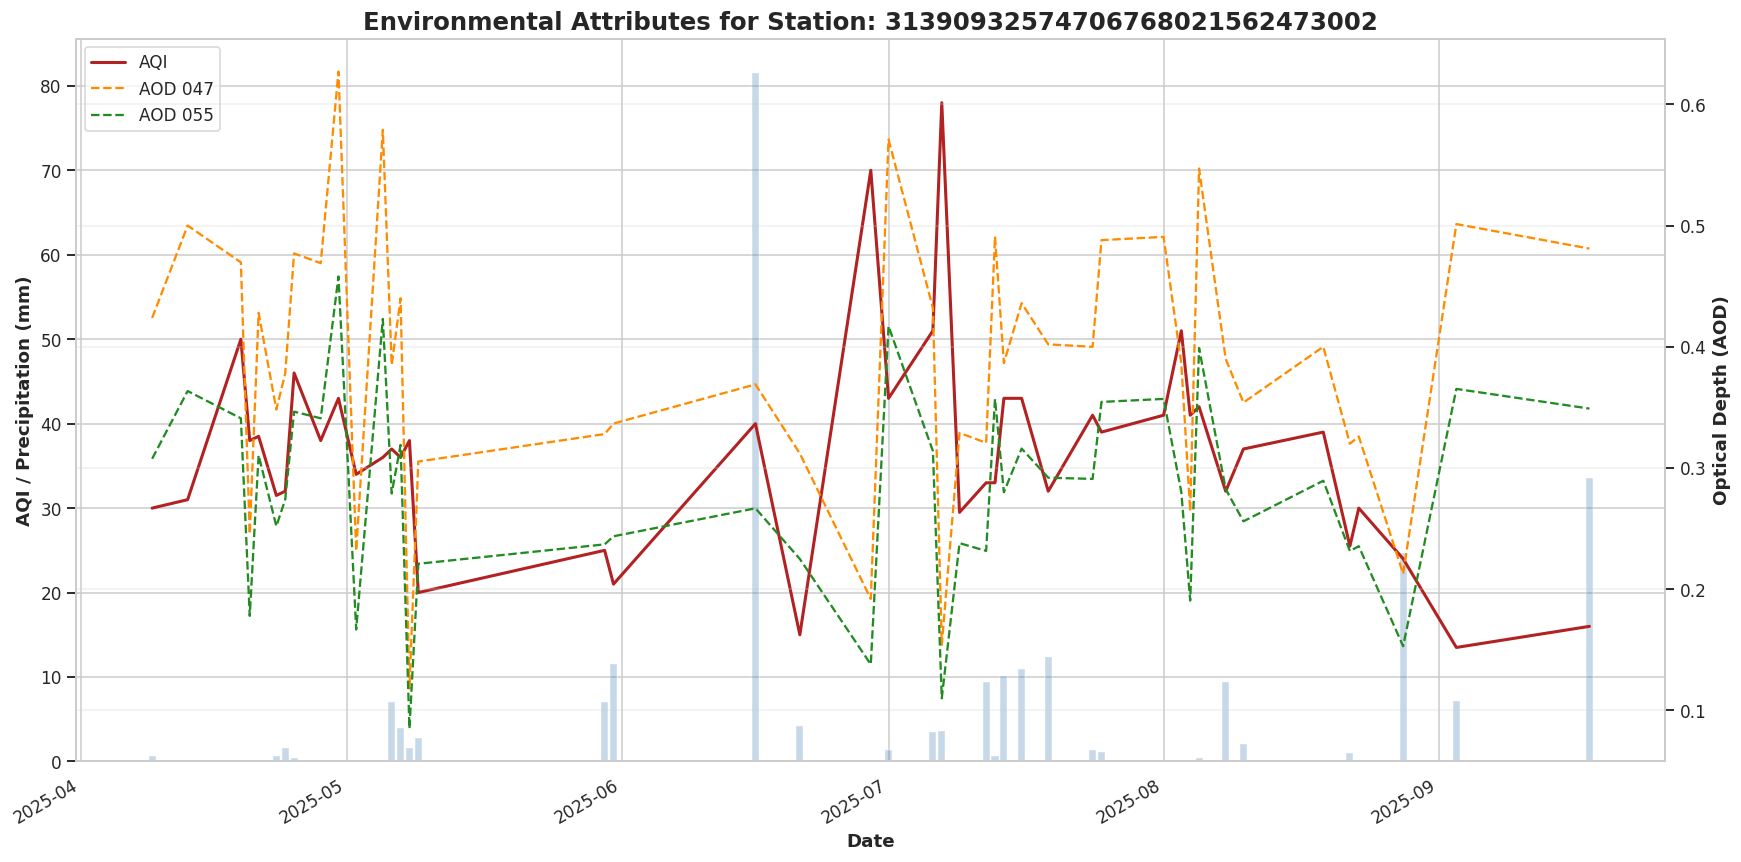

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Ensure the date column is in datetime format
df['date'] = pd.to_datetime(df['date'])

# 2. Loop through each unique Station ID
for station_id, group in df.groupby('station_id'):
    
    # Sort by date to ensure the lines don't zig-zag
    group = group.sort_values('date')
    
    fig, ax1 = plt.subplots(figsize=(16, 8))
    
    # --- Primary Y-Axis (Left): AQI and GPM ---
    # Plotting GPM as a bar in the background
    ax1.bar(group['date'], group['total_accum_day'], color='steelblue', alpha=0.3, label='Precipitation (GPM)')
    # Plotting AQI as a line
    line1, = ax1.plot(group['date'], group['AQI'], color='firebrick', linewidth=2, label='AQI')
    
    ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax1.set_ylabel('AQI / Precipitation (mm)', fontsize=12, fontweight='bold')
    
    # --- Secondary Y-Axis (Right): AOD ---
    # Create a twin axis for the Optical Depth values (different scale)
    ax2 = ax1.twinx()
    line2, = ax2.plot(group['date'], group['Optical_Depth_047'], color='darkorange', linestyle='--', label='AOD 047')
    line3, = ax2.plot(group['date'], group['Optical_Depth_055'], color='forestgreen', linestyle='--', label='AOD 055')
    
    ax2.set_ylabel('Optical Depth (AOD)', fontsize=12, fontweight='bold')

    # Add title and formatting
    plt.title(f'Environmental Attributes for Station: {station_id}', fontsize=16, fontweight='bold')
    
    # Combine legends from both axes
    lines = [line1, line2, line3]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left')

    # Tilt dates for readability
    fig.autofmt_xdate()
    
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()